# Medicare Geographic Spending Disparities  
## Predicting Unexplained County-Level Cost Variation  
  
**Author:** Hyeon Kang  
**Date:** Mar 21, 2026  
  
### Contents  
Part 1: Data Acquisition and Exploratory Data Analysis  
Part 2: Preprocessing & Feature Engineering  
Part 3: Model Development  
Part 4: Evaluation, Interpretation & Business Outputs

# Part 1: Data Acquisition and Exploratory Data Analysis  
  
1. Environment Setup
2. Data Loading and Quality Check
3. FIPS Code Validation
4. Exploratory Data Analysis

## 1. Environment Setup

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

SEED = 42
np.random.seed(SEED)

DATA_DIR = 'data'

PATHS = {
    'medicare'  : os.path.join(DATA_DIR, 'Medicare_Physician_Other_Practitioners_by_Provider_2023.csv'),
    'hospital'  : os.path.join(DATA_DIR, 'Hospital_General_Information.csv'),
    'acs_income': os.path.join(DATA_DIR, 'ACSST5Y2022.S1901', 'ACSST5Y2022.S1901-Data.csv'),
    'acs_insure': os.path.join(DATA_DIR, 'ACSST5Y2022.S2701', 'ACSST5Y2022.S2701-Data.csv'),
    'acs_poverty': os.path.join(DATA_DIR, 'ACSDT5Y2022.B17001', 'ACSDT5Y2022.B17001-Data.csv'),
    'ahrf'      : os.path.join(DATA_DIR, 'AHRF_CSV_2022-2023', 'DATA', 'ahrf2023.csv'),
}

for name, path in PATHS.items():
    status = 'OK' if os.path.exists(path) else 'MISSING'
    print(f'  {status}  {name}: {path}')

print()
print('Library versions:')
print(f'  numpy   {np.__version__}')
print(f'  pandas  {pd.__version__}')

  OK  medicare: data/Medicare_Physician_Other_Practitioners_by_Provider_2023.csv
  OK  hospital: data/Hospital_General_Information.csv
  OK  acs_income: data/ACSST5Y2022.S1901/ACSST5Y2022.S1901-Data.csv
  OK  acs_insure: data/ACSST5Y2022.S2701/ACSST5Y2022.S2701-Data.csv
  OK  acs_poverty: data/ACSDT5Y2022.B17001/ACSDT5Y2022.B17001-Data.csv
  OK  ahrf: data/AHRF_CSV_2022-2023/DATA/ahrf2023.csv

Library versions:
  numpy   2.2.3
  pandas  2.2.3


## 2. Data Loading and Quality Check

### 2.1 CMS Medicare Provider Utilization (2023)

In [5]:
# Load Medicare provider-level data
# Key columns: provider location FIPS, payment amounts, beneficiary counts
MEDICARE_COLS = [
    'Rndrng_NPI',
    'Rndrng_Prvdr_State_FIPS',
    'Rndrng_Prvdr_Zip5',
    'Rndrng_Prvdr_State_Abrvtn',
    'Rndrng_Prvdr_Type',
    'Rndrng_Prvdr_Cntry',
    'Tot_Benes',
    'Tot_Srvcs',
    'Tot_Mdcr_Pymt_Amt',    # actual Medicare payment
    'Tot_Mdcr_Stdzd_Amt',   # standardized payment (removes geographic price differences)
    'Tot_Sbmtd_Chrg',       # submitted charges
    'Bene_Avg_Age',
    'Bene_Avg_Risk_Scre',
    'Bene_Dual_Cnt',        # dual Medicare-Medicaid enrollees
]

medicare = pd.read_csv(PATHS['medicare'], usecols=MEDICARE_COLS, low_memory=False)

print('Shape:', medicare.shape)
print()
print('Missing values (%):')
miss = medicare.isnull().mean().mul(100).round(2)
print(miss[miss > 0].to_string() if miss[miss > 0].any() else '  None')
print()
print('Data types:')
print(medicare.dtypes.to_string())

Shape: (1259343, 14)

Missing values (%):
Bene_Dual_Cnt    32.84

Data types:
Rndrng_NPI                     int64
Rndrng_Prvdr_State_Abrvtn     object
Rndrng_Prvdr_State_FIPS       object
Rndrng_Prvdr_Zip5             object
Rndrng_Prvdr_Cntry            object
Rndrng_Prvdr_Type             object
Tot_Benes                      int64
Tot_Srvcs                    float64
Tot_Sbmtd_Chrg               float64
Tot_Mdcr_Pymt_Amt            float64
Tot_Mdcr_Stdzd_Amt           float64
Bene_Avg_Age                   int64
Bene_Dual_Cnt                float64
Bene_Avg_Risk_Scre           float64


In [6]:
# Filter to US providers only (exclude territories and foreign addresses)
# Keep only rows where state FIPS is a 2-digit numeric code (01-56)
medicare = medicare[medicare['Rndrng_Prvdr_Cntry'] == 'US'].copy()

# Convert state FIPS to zero-padded 2-digit string
medicare['state_fips'] = medicare['Rndrng_Prvdr_State_FIPS'].astype(str).str.zfill(2)

# Convert zip to zero-padded 5-digit string
medicare['zip5'] = medicare['Rndrng_Prvdr_Zip5'].astype(str).str.zfill(5)

# Convert payment columns to numeric (suppress errors for suppressed values)
for col in ['Tot_Benes', 'Tot_Srvcs', 'Tot_Mdcr_Pymt_Amt', 'Tot_Mdcr_Stdzd_Amt', 'Tot_Sbmtd_Chrg']:
    medicare[col] = pd.to_numeric(medicare[col], errors='coerce')

print('After US filter — shape:', medicare.shape)
print('Unique state FIPS codes:', sorted(medicare['state_fips'].unique()))

After US filter — shape: (1259266, 16)
Unique state FIPS codes: ['01', '02', '04', '05', '06', '08', '09', '10', '11', '12', '13', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '44', '45', '46', '47', '48', '49', '50', '51', '53', '54', '55', '56', '60', '66', '69', '72', '78', '9A', '9B', '9C', '9D', 'nan']


In [8]:
# Summary statistics for key payment and beneficiary columns
summary_cols = ['Tot_Benes', 'Tot_Mdcr_Pymt_Amt', 'Tot_Mdcr_Stdzd_Amt', 'Bene_Avg_Age', 'Bene_Avg_Risk_Scre']
medicare[summary_cols].describe().round(2)

,Tot_Benes,Tot_Mdcr_Pymt_Amt,Tot_Mdcr_Stdzd_Amt,Bene_Avg_Age,Bene_Avg_Risk_Scre
count,1259266.00,1.259266e+06,1.259266e+06,1259266.00,1259266.00
mean,300.35,8.962287e+04,8.889515e+04,72.69,1.57
std,3002.78,7.268424e+05,7.176973e+05,5.09,0.81
min,11.00,0.000000e+00,0.000000e+00,7.00,0.33
25%,54.00,9.921860e+03,9.980200e+03,71.00,1.02
50%,136.00,2.739937e+04,2.753322e+04,73.00,1.34
75%,295.00,6.857504e+04,6.831815e+04,75.00,1.92
max,1559155.00,2.993196e+08,2.994217e+08,94.00,13.66


### 2.2 CMS Hospital General Information

In [12]:
# Load hospital-level data
# Key columns: location, type, ownership, star rating
HOSPITAL_COLS = [
    'Facility ID',
    'Facility Name',
    'State',
    'ZIP Code',
    'County/Parish',
    'Hospital Type',
    'Hospital Ownership',
    'Emergency Services',
    'Hospital overall rating',
]

hospital = pd.read_csv(PATHS['hospital'], usecols=HOSPITAL_COLS, low_memory=False)

print('Shape:', hospital.shape)
print()
print('Missing values (%):')
miss = hospital.isnull().mean().mul(100).round(2)
print(miss[miss > 0].to_string() if miss[miss > 0].any() else '  None')
print()
print('Hospital Type distribution:')
print(hospital['Hospital Type'].value_counts().to_string())

Shape: (5421, 9)

Missing values (%):
  None

Hospital Type distribution:
Hospital Type
Acute Care Hospitals                    3120
Critical Access Hospitals               1375
Psychiatric                              626
Acute Care - Veterans Administration     132
Childrens                                 94
Rural Emergency Hospital                  38
Acute Care - Department of Defense        32
Long-term                                  4


In [14]:
# Standardize ZIP code format to 5-digit string
hospital['zip5'] = hospital['ZIP Code'].astype(str).str.zfill(5).str[:5]

# Convert star rating to numeric (non-numeric values become NaN)
hospital['rating_numeric'] = pd.to_numeric(hospital['Hospital overall rating'], errors='coerce')

print('Rating distribution:')
print(hospital['rating_numeric'].value_counts(dropna=False).sort_index().to_string())

Rating distribution:
rating_numeric
1.0     229
2.0     649
3.0     937
4.0     765
5.0     289
NaN    2552


### 2.3 ACS 5-Year 2022 — Income, Insurance, Poverty

In [17]:
# S1901: Median Household Income
# Row 0 = column codes
# Row 1 = human-readable labels; skip row 1 when loading data
acs_income = pd.read_csv(PATHS['acs_income'], skiprows=[1], low_memory=False)

# Extract 5-digit FIPS from GEO_ID format '0500000US<FIPS>'
acs_income['county_fips'] = acs_income['GEO_ID'].str[-5:]

# Select: median household income estimate
acs_income = acs_income[['county_fips', 'NAME', 'S1901_C01_012E']].copy()
acs_income.columns = ['county_fips', 'county_name', 'median_hh_income']
acs_income['median_hh_income'] = pd.to_numeric(acs_income['median_hh_income'], errors='coerce')

# Drop header row (county_fips == '0US' or other non-county rows)
acs_income = acs_income[acs_income['county_fips'].str.match(r'^\d{5}$')].copy()

print('ACS Income — shape:', acs_income.shape)
print('Missing median income:', acs_income['median_hh_income'].isnull().sum())
acs_income.head(3)

ACS Income — shape: (3222, 3)
Missing median income: 1


,county_fips,county_name,median_hh_income
0,01001,"Autauga County, Alabama",68315.0
1,01003,"Baldwin County, Alabama",71039.0
2,01005,"Barbour County, Alabama",39712.0


In [19]:
# S2701: Uninsured Rate
# S2701_C05_001E = Percent Uninsured, civilian noninstitutionalized population
acs_insure = pd.read_csv(PATHS['acs_insure'], skiprows=[1],
                         usecols=['GEO_ID', 'S2701_C05_001E'], low_memory=False)

acs_insure['county_fips'] = acs_insure['GEO_ID'].str[-5:]
acs_insure = acs_insure[acs_insure['county_fips'].str.match(r'^\d{5}$')].copy()
acs_insure = acs_insure[['county_fips', 'S2701_C05_001E']].copy()
acs_insure.columns = ['county_fips', 'uninsured_pct']
acs_insure['uninsured_pct'] = pd.to_numeric(acs_insure['uninsured_pct'], errors='coerce')

print('ACS Insurance — shape:', acs_insure.shape)
print('Missing uninsured rate:', acs_insure['uninsured_pct'].isnull().sum())

ACS Insurance — shape: (3222, 2)
Missing uninsured rate: 0


In [21]:
# B17001: Poverty Rate
# B17001_001E = total population, B17001_002E = below poverty level
# Poverty rate = B17001_002E / B17001_001E * 100
acs_poverty = pd.read_csv(PATHS['acs_poverty'], skiprows=[1],
                          usecols=['GEO_ID', 'B17001_001E', 'B17001_002E'], low_memory=False)

acs_poverty['county_fips'] = acs_poverty['GEO_ID'].str[-5:]
acs_poverty = acs_poverty[acs_poverty['county_fips'].str.match(r'^\d{5}$')].copy()

acs_poverty['B17001_001E'] = pd.to_numeric(acs_poverty['B17001_001E'], errors='coerce')
acs_poverty['B17001_002E'] = pd.to_numeric(acs_poverty['B17001_002E'], errors='coerce')

# Compute poverty rate as a percentage
acs_poverty['poverty_rate'] = (acs_poverty['B17001_002E'] / acs_poverty['B17001_001E'] * 100).round(2)
acs_poverty = acs_poverty[['county_fips', 'poverty_rate']].copy()

print('ACS Poverty — shape:', acs_poverty.shape)
print('Missing poverty rate:', acs_poverty['poverty_rate'].isnull().sum())

ACS Poverty — shape: (3222, 2)
Missing poverty rate: 0


### 2.4 HRSA Area Health Resource File (2022-2023)

In [24]:
# AHRF has 6,000+ variables; select only variables needed for feature engineering
AHRF_COLS = [
    'fips_st_cnty',              # 5-digit county FIPS
    'st_name',
    'cnty_name',
    'cens_regn',                 # Census region (1=NE, 2=MW, 3=S, 4=W)
    'cens_divsn',                # Census division
    'hpsa_prim_care_23',         # HPSA primary care designation (2023)
    'phys_nf_prim_care_pc_exc_rsdt_21',  # Primary care physicians per 100k pop (excl. residents)
    'md_nf_activ_21',            # Total active MDs (non-federal)
    'hosp_beds_21',              # Total hospital beds
    'popn_est_22',               # Population estimate 2022
]

# AHRF file uses Latin-1 encoding (common for older government datasets)
ahrf = pd.read_csv(PATHS['ahrf'], usecols=AHRF_COLS, low_memory=False, encoding='latin-1')

# Zero-pad FIPS to 5 digits
ahrf['county_fips'] = ahrf['fips_st_cnty'].astype(str).str.zfill(5)

print('Shape:', ahrf.shape)
print()
print('Missing values (%):')
miss = ahrf.isnull().mean().mul(100).round(2)
print(miss[miss > 0].to_string() if miss[miss > 0].any() else '  None')

Shape: (3231, 11)

Missing values (%):
cens_divsn                          2.54
hpsa_prim_care_23                   0.22
phys_nf_prim_care_pc_exc_rsdt_21    0.19
md_nf_activ_21                      0.19
hosp_beds_21                        0.15
popn_est_22                         0.53


In [26]:
# Convert numeric columns
numeric_ahrf = [
    'hpsa_prim_care_23',
    'phys_nf_prim_care_pc_exc_rsdt_21',
    'md_nf_activ_21',
    'hosp_beds_21',
    'popn_est_22',
]
for col in numeric_ahrf:
    ahrf[col] = pd.to_numeric(ahrf[col], errors='coerce')

print('HPSA designation distribution (2023):')
print(ahrf['hpsa_prim_care_23'].value_counts(dropna=False).to_string())
print()
print('Census Region distribution:')
print(ahrf['cens_regn'].value_counts(dropna=False).sort_index().to_string())

HPSA designation distribution (2023):
hpsa_prim_care_23
2.0    2044
1.0     782
0.0     398
NaN       7

Census Region distribution:
cens_regn
1     217
2    1136
3    1424
4     453
9       1


## 3. FIPS Code Validation and Coverage

In [29]:
# Validate FIPS coverage across datasets
# AHRF is the authoritative county list (3,232 counties)

# Extract county FIPS from Medicare (state_fips + zip → we will map in preprocessing)
# For now, check unique state FIPS coverage
medicare_states = set(medicare['state_fips'].dropna().unique())
ahrf_fips       = set(ahrf['county_fips'].dropna().unique())
income_fips     = set(acs_income['county_fips'].dropna().unique())
insure_fips     = set(acs_insure['county_fips'].dropna().unique())
poverty_fips    = set(acs_poverty['county_fips'].dropna().unique())

print('FIPS Coverage Summary')
print('-' * 40)
print(f'AHRF counties (reference):     {len(ahrf_fips):>5}')
print(f'ACS Income counties:           {len(income_fips):>5}')
print(f'ACS Insurance counties:        {len(insure_fips):>5}')
print(f'ACS Poverty counties:          {len(poverty_fips):>5}')
print(f'Medicare provider states:      {len(medicare_states):>5}')
print()
print('ACS Income ∩ AHRF:             ', len(income_fips & ahrf_fips))
print('ACS Insurance ∩ AHRF:          ', len(insure_fips & ahrf_fips))
print('ACS Poverty ∩ AHRF:            ', len(poverty_fips & ahrf_fips))
print()
print('ACS Income not in AHRF:        ', len(income_fips - ahrf_fips))
print('Sample FIPS not in AHRF:', list(income_fips - ahrf_fips)[:5])

FIPS Coverage Summary
----------------------------------------
AHRF counties (reference):      3231
ACS Income counties:            3222
ACS Insurance counties:         3222
ACS Poverty counties:           3222
Medicare provider states:         61

ACS Income ∩ AHRF:              3213
ACS Insurance ∩ AHRF:           3213
ACS Poverty ∩ AHRF:             3213

ACS Income not in AHRF:         9
Sample FIPS not in AHRF: ['09140', '09180', '09150', '09170', '09120']


In [31]:
# Identify FIPS codes that exist in all ACS datasets + AHRF
# These will be the candidate counties for the final analysis
common_fips = income_fips & insure_fips & poverty_fips & ahrf_fips

print(f'Counties in ALL four datasets (AHRF + 3 ACS): {len(common_fips)}')

# Exclude non-county FIPS (e.g., 72xxx = Puerto Rico)
# Standard US counties have state FIPS 01-56 (excluding 03, 07, 14, 43, 52)
valid_fips = {f for f in common_fips if f[:2].isdigit() and 1 <= int(f[:2]) <= 56}
print(f'After excluding territories:                  {len(valid_fips)}')

Counties in ALL four datasets (AHRF + 3 ACS): 3213
After excluding territories:                  3135


## 4. Exploratory Data Analysis

### 4.1 County-Level Medicare Spending Distribution (Preview)
We compute a preliminary county-level per-beneficiary spending here for EDA purposes.  
Full residual target construction happens in Notebook 2.

In [35]:
# Build a preliminary county FIPS from state FIPS + zip code
# Note: this is approximate; full ZIP→FIPS crosswalk applied in Notebook 2

# Drop rows missing state FIPS, payment, or beneficiary count
med_clean = medicare.dropna(subset=['Rndrng_Prvdr_State_FIPS', 'Tot_Mdcr_Pymt_Amt', 'Tot_Benes']).copy()

# For EDA: aggregate by state FIPS to get state-level summary
state_spending = (
    med_clean
    .groupby('state_fips')
    .agg(
        total_payment=('Tot_Mdcr_Pymt_Amt', 'sum'),
        total_benes=('Tot_Benes', 'sum'),
        provider_count=('Rndrng_NPI', 'nunique'),
    )
    .reset_index()
)
state_spending['payment_per_bene'] = state_spending['total_payment'] / state_spending['total_benes']

print('State-level per-beneficiary spending summary:')
state_spending['payment_per_bene'].describe().round(2)

State-level per-beneficiary spending summary:


count     60.00
mean     274.12
std       77.64
min       60.84
25%      232.89
50%      281.62
75%      308.45
max      525.28
Name: payment_per_bene, dtype: float64

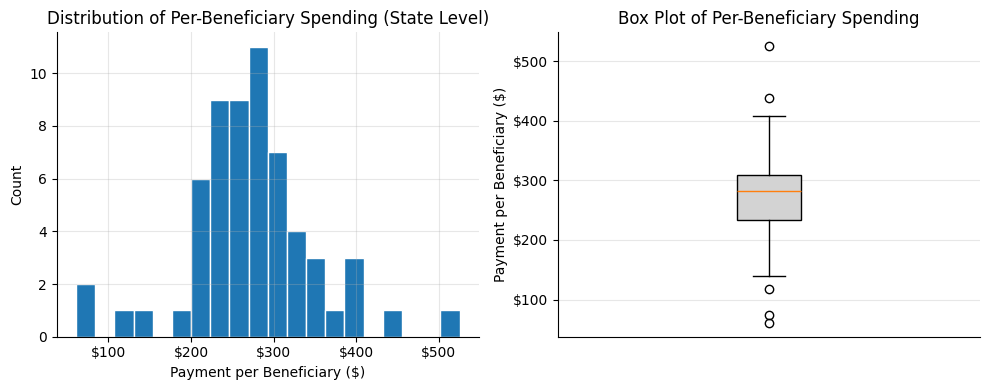

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Histogram of state-level per-beneficiary spending
axes[0].hist(state_spending['payment_per_bene'].dropna(), bins=20, edgecolor='white')
axes[0].set_xlabel('Payment per Beneficiary ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Per-Beneficiary Spending (State Level)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Box plot
axes[1].boxplot(state_spending['payment_per_bene'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgray'))
axes[1].set_ylabel('Payment per Beneficiary ($)')
axes[1].set_title('Box Plot of Per-Beneficiary Spending')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('eda_01_spending_distribution.png', bbox_inches='tight')
plt.show()

### 4.2 SDOH Variable Distributions

In [40]:
# Merge ACS tables for joint distribution view
acs_merged = (
    acs_income
    .merge(acs_insure, on='county_fips', how='inner')
    .merge(acs_poverty, on='county_fips', how='inner')
)
print('ACS merged shape:', acs_merged.shape)
acs_merged[['median_hh_income', 'uninsured_pct', 'poverty_rate']].describe().round(2)

ACS merged shape: (3222, 5)


,median_hh_income,uninsured_pct,poverty_rate
count,3221.00,3222.00,3222.00
mean,62326.87,9.43,15.10
std,17770.57,5.06,7.71
min,14525.00,0.00,1.60
25%,51823.00,5.70,10.16
50%,60461.00,8.20,13.55
75%,70379.00,11.90,17.91
max,170463.00,45.10,66.32


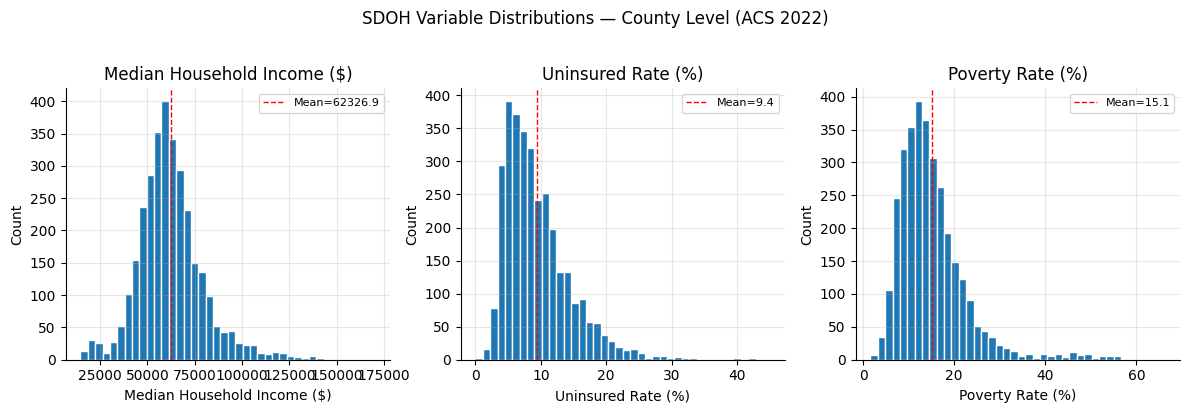

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sdoh_vars = [
    ('median_hh_income', 'Median Household Income ($)'),
    ('uninsured_pct',    'Uninsured Rate (%)'),
    ('poverty_rate',     'Poverty Rate (%)'),
]

for ax, (col, label) in zip(axes, sdoh_vars):
    data = acs_merged[col].dropna()
    ax.hist(data, bins=40, edgecolor='white')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(label)
    # Add mean line
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean={data.mean():.1f}')
    ax.legend(fontsize=8)

plt.suptitle('SDOH Variable Distributions — County Level (ACS 2022)', y=1.02)
plt.tight_layout()
plt.savefig('eda_02_sdoh_distributions.png', bbox_inches='tight')
plt.show()

### 4.3 Healthcare Supply Variable Distributions

In [45]:
# Compute per-capita physician and bed density using AHRF population
ahrf['pcp_per_100k']  = (ahrf['phys_nf_prim_care_pc_exc_rsdt_21'] / ahrf['popn_est_22'] * 100_000).round(2)
ahrf['beds_per_1000'] = (ahrf['hosp_beds_21'] / ahrf['popn_est_22'] * 1_000).round(2)

# Replace infinite values (division by zero for tiny counties)
ahrf.replace([np.inf, -np.inf], np.nan, inplace=True)

print('Healthcare supply summary:')
ahrf[['pcp_per_100k', 'beds_per_1000', 'hpsa_prim_care_23']].describe().round(2)

Healthcare supply summary:


,pcp_per_100k,beds_per_1000,hpsa_prim_care_23
count,3214.00,3214.00,3224.00
mean,50.97,2.79,1.51
std,38.00,4.93,0.70
min,0.00,0.00,0.00
25%,26.47,0.48,1.00
50%,45.18,1.70,2.00
75%,68.98,3.36,2.00
max,580.40,134.33,2.00


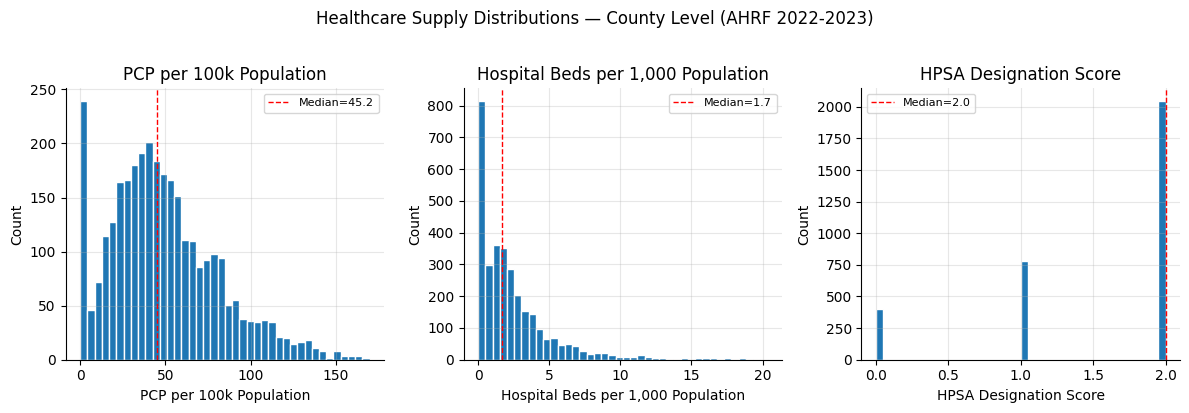

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

supply_vars = [
    ('pcp_per_100k',     'PCP per 100k Population'),
    ('beds_per_1000',    'Hospital Beds per 1,000 Population'),
    ('hpsa_prim_care_23','HPSA Designation Score'),
]

for ax, (col, label) in zip(axes, supply_vars):
    data = ahrf[col].dropna()
    # Cap extreme outliers at 99th percentile for display
    cap = data.quantile(0.99)
    data_capped = data[data <= cap]
    ax.hist(data_capped, bins=40, edgecolor='white')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(label)
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1,
               label=f'Median={data.median():.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Healthcare Supply Distributions — County Level (AHRF 2022-2023)', y=1.02)
plt.tight_layout()
plt.savefig('eda_03_supply_distributions.png', bbox_inches='tight')
plt.show()

### 4.4 Correlation Heatmap — SDOH and Healthcare Supply

In [50]:
# Merge all feature datasets for correlation analysis
# State-level spending + ACS + AHRF supply variables
ahrf_slim = ahrf[['county_fips', 'pcp_per_100k', 'beds_per_1000', 'hpsa_prim_care_23', 'cens_regn']].copy()

corr_df = acs_merged.merge(ahrf_slim, on='county_fips', how='inner')

print('Correlation dataset shape:', corr_df.shape)

# Numeric columns for correlation
corr_cols = ['median_hh_income', 'uninsured_pct', 'poverty_rate',
             'pcp_per_100k', 'beds_per_1000', 'hpsa_prim_care_23']

corr_matrix = corr_df[corr_cols].corr().round(2)
print()
print('Correlation Matrix:')
print(corr_matrix.to_string())

Correlation dataset shape: (3213, 9)

Correlation Matrix:
                   median_hh_income  uninsured_pct  poverty_rate  pcp_per_100k  beds_per_1000  hpsa_prim_care_23
median_hh_income               1.00          -0.25         -0.75          0.24          -0.07              -0.10
uninsured_pct                 -0.25           1.00          0.22         -0.19           0.00               0.05
poverty_rate                  -0.75           0.22          1.00         -0.11           0.01               0.06
pcp_per_100k                   0.24          -0.19         -0.11          1.00           0.25               0.09
beds_per_1000                 -0.07           0.00          0.01          0.25           1.00               0.04
hpsa_prim_care_23             -0.10           0.05          0.06          0.09           0.04               1.00


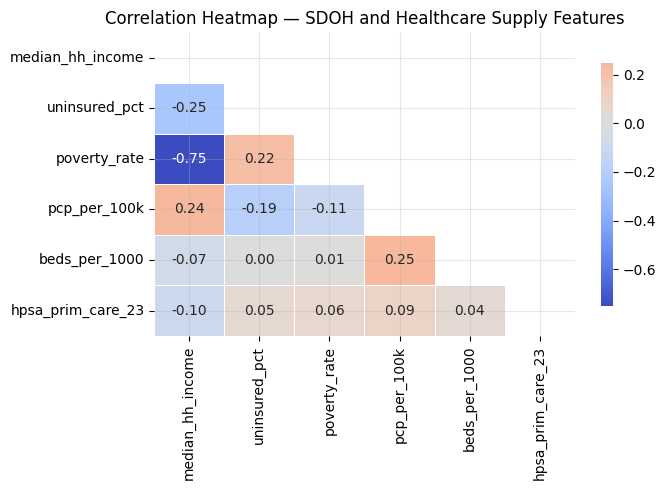

In [52]:
fig, ax = plt.subplots(figsize=(7, 5))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show only lower triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8},
)
ax.set_title('Correlation Heatmap — SDOH and Healthcare Supply Features')

plt.tight_layout()
plt.savefig('eda_04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

### 4.5 Choropleth Map — State-Level Medicare Spending

In [55]:
import folium
from folium.utilities import parse_options
import json
import urllib.request
import ssl

# Download US state GeoJSON (from public source — used for visualization only)
GEOJSON_URL = 'https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/us-states.json'
GEOJSON_PATH = 'us_states.json'

if not os.path.exists(GEOJSON_PATH):
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    with urllib.request.urlopen(GEOJSON_URL, context=ctx) as response:
        with open(GEOJSON_PATH, 'wb') as f:
            f.write(response.read())
    print('Downloaded GeoJSON')
else:
    print('GeoJSON already exists')

# Map state FIPS to state abbreviations for join
# Use AHRF state lookup
state_lookup = ahrf[['county_fips', 'st_name']].copy()
state_lookup['state_fips'] = state_lookup['county_fips'].str[:2]
state_abbrev_map = (
    medicare[['state_fips', 'Rndrng_Prvdr_State_Abrvtn']]
    .drop_duplicates()
    .dropna()
    .rename(columns={'Rndrng_Prvdr_State_Abrvtn': 'state_abbrev'})
)

state_map_df = state_spending.merge(state_abbrev_map, on='state_fips', how='left')
state_map_df = state_map_df.dropna(subset=['state_abbrev', 'payment_per_bene'])

print('States available for map:', len(state_map_df))
state_map_df[['state_abbrev', 'payment_per_bene']].sort_values('payment_per_bene', ascending=False).head(10)

GeoJSON already exists
States available for map: 60


,state_abbrev,payment_per_bene
59,XX,525.275668
2,AZ,438.228595
28,NV,408.187878
4,CA,398.592440
1,AK,387.322235
52,GU,374.482657
44,UT,352.138361
9,FL,350.681627
20,MD,346.705165
53,MP,332.415492


In [57]:
# Create choropleth map using folium
m = folium.Map(location=[38, -96], zoom_start=4, tiles='CartoDB positron')

folium.Choropleth(
    geo_data=GEOJSON_PATH,
    data=state_map_df,
    columns=['state_abbrev', 'payment_per_bene'],
    key_on='feature.id',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Medicare Payment per Beneficiary ($)',
    nan_fill_color='white',
).add_to(m)

# Save to HTML
m.save('eda_05_spending_map_state.html')
print('Map saved to eda_05_spending_map_state.html')
m

Map saved to eda_05_spending_map_state.html


### 4.6 Outlier Identification

In [60]:
# Identify states with unusually high or low per-beneficiary spending
# Outlier threshold: beyond 1.5 * IQR
spend = state_spending['payment_per_bene'].dropna()
q1, q3 = spend.quantile(0.25), spend.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = state_spending[
    (state_spending['payment_per_bene'] < lower_bound) |
    (state_spending['payment_per_bene'] > upper_bound)
].copy()

outliers = outliers.merge(state_abbrev_map, on='state_fips', how='left')

print(f'IQR range: ${lower_bound:,.0f} – ${upper_bound:,.0f}')
print(f'Outlier states: {len(outliers)}')
print()
print(outliers[['state_abbrev', 'state_fips', 'payment_per_bene', 'total_benes']]
      .sort_values('payment_per_bene', ascending=False)
      .to_string(index=False))

IQR range: $120 – $422
Outlier states: 5

state_abbrev state_fips  payment_per_bene  total_benes
          XX         9D        525.275668         8605
          AZ         04        438.228595      8292491
          AP         9C        117.541651        15962
          AS         60         73.640521           96
          AA         9A         60.840804        11489


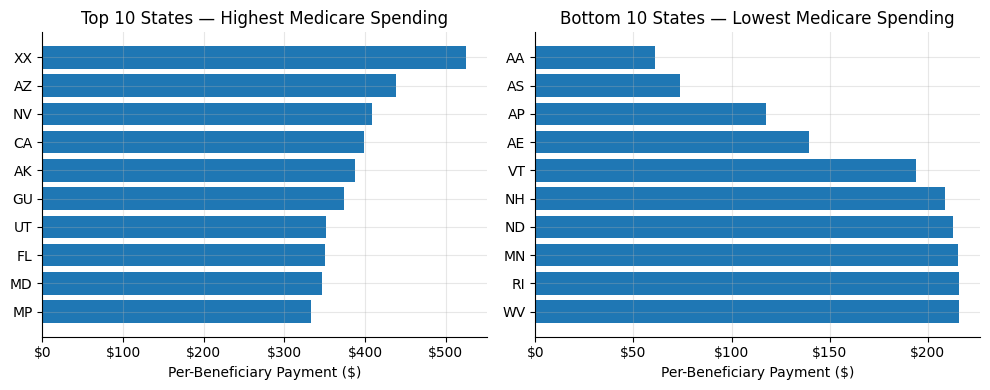

In [62]:
# Visualize top / bottom states by spending
top_n = 10
plot_df = state_map_df.sort_values('payment_per_bene', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Top 10 states (highest spending)
top = plot_df.head(top_n)
axes[0].barh(top['state_abbrev'][::-1], top['payment_per_bene'][::-1])
axes[0].set_xlabel('Per-Beneficiary Payment ($)')
axes[0].set_title(f'Top {top_n} States — Highest Medicare Spending')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Bottom 10 states (lowest spending)
bot = plot_df.tail(top_n)
axes[1].barh(bot['state_abbrev'], bot['payment_per_bene'])
axes[1].set_xlabel('Per-Beneficiary Payment ($)')
axes[1].set_title(f'Bottom {top_n} States — Lowest Medicare Spending')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('eda_06_top_bottom_states.png', bbox_inches='tight')
plt.show()

### Summary 1

**Key EDA findings:**
- State-level Medicare per-beneficiary spending shows meaningful variation across the US.
- SDOH variables (income, uninsured rate, poverty rate) are highly correlated — Ridge regression in Part 3 will handle multicollinearity.
- HPSA designation and PCP density distributions are right-skewed, with rural counties showing the greatest shortages.
- Outlier states (if any) have been identified and documented.

# Part 2. Preprocessing and Feature Engineering
5. Data cleaning and county-level aggregation
6. Feature engineering
7. Scikit-learn pipeline

## 5. Data Cleaning and County-Level Aggregation

In [68]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import joblib

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

SEED = 42
DATA_DIR = 'data'

PATHS = {
    'medicare'   : os.path.join(DATA_DIR, 'Medicare_Physician_Other_Practitioners_by_Provider_2023.csv'),
    'hospital'   : os.path.join(DATA_DIR, 'Hospital_General_Information.csv'),
    'acs_income' : os.path.join(DATA_DIR, 'ACSST5Y2022.S1901', 'ACSST5Y2022.S1901-Data.csv'),
    'acs_insure' : os.path.join(DATA_DIR, 'ACSST5Y2022.S2701', 'ACSST5Y2022.S2701-Data.csv'),
    'acs_poverty': os.path.join(DATA_DIR, 'ACSDT5Y2022.B17001', 'ACSDT5Y2022.B17001-Data.csv'),
    'ahrf'       : os.path.join(DATA_DIR, 'AHRF_CSV_2022-2023', 'DATA', 'ahrf2023.csv'),
}

print('Paths configured.')

Paths configured.


### 5.1 Build ZIP → County FIPS Crosswalk

In [71]:
# Source: Census Bureau 2020 ZCTA-to-County relationship file (free, no auth)
# When a ZIP spans multiple counties, assign to the county with the largest land area.

import urllib.request
import ssl

CROSSWALK_URL  = 'https://www2.census.gov/geo/docs/maps-data/data/rel2020/zcta520/tab20_zcta520_county20_natl.txt'
CROSSWALK_PATH = 'zcta_county_crosswalk.txt'

if not os.path.exists(CROSSWALK_PATH):
    print('Downloading Census ZCTA-to-County crosswalk...')
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    with urllib.request.urlopen(CROSSWALK_URL, context=ctx) as response:
        with open(CROSSWALK_PATH, 'wb') as f:
            f.write(response.read())
    print('Downloaded.')
else:
    print('Crosswalk file already exists.')

# Load only the columns needed
zcta_raw = pd.read_csv(
    CROSSWALK_PATH, sep='|', dtype=str, encoding='utf-8-sig',
    usecols=['GEOID_ZCTA5_20', 'GEOID_COUNTY_20', 'AREALAND_PART'],
)
zcta_raw.columns = ['zip5', 'county_fips', 'area_land']

# Drop rows where ZIP or county FIPS is missing
zcta_raw = zcta_raw.dropna(subset=['zip5', 'county_fips']).copy()
zcta_raw['zip5']        = zcta_raw['zip5'].str.strip().str.zfill(5)
zcta_raw['county_fips'] = zcta_raw['county_fips'].str.strip().str.zfill(5)
zcta_raw['area_land']   = pd.to_numeric(zcta_raw['area_land'], errors='coerce').fillna(0)

# For ZIPs that span multiple counties, keep the county with the most land area
zip_to_fips = (
    zcta_raw
    .sort_values('area_land', ascending=False)
    .drop_duplicates(subset='zip5', keep='first')
    [['zip5', 'county_fips']]
    .reset_index(drop=True)
)

print(f'ZIP→FIPS crosswalk entries: {len(zip_to_fips)}')
print(f'Sample:')
print(zip_to_fips.head(5).to_string(index=False))

# Load Medicare data
MEDICARE_COLS = [
    'Rndrng_NPI', 'Rndrng_Prvdr_State_FIPS', 'Rndrng_Prvdr_Zip5',
    'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_Cntry',
    'Tot_Benes', 'Tot_Srvcs', 'Tot_Mdcr_Pymt_Amt', 'Tot_Mdcr_Stdzd_Amt',
    'Tot_Sbmtd_Chrg', 'Bene_Avg_Age', 'Bene_Avg_Risk_Scre', 'Bene_Dual_Cnt',
]
medicare = pd.read_csv(PATHS['medicare'], usecols=MEDICARE_COLS, low_memory=False)
medicare = medicare[medicare['Rndrng_Prvdr_Cntry'] == 'US'].copy()
medicare['zip5'] = medicare['Rndrng_Prvdr_Zip5'].astype(str).str.zfill(5).str[:5]

for col in ['Tot_Benes', 'Tot_Srvcs', 'Tot_Mdcr_Pymt_Amt', 'Tot_Mdcr_Stdzd_Amt', 'Tot_Sbmtd_Chrg']:
    medicare[col] = pd.to_numeric(medicare[col], errors='coerce')

unique_zips = medicare['zip5'].dropna().unique()
print(f'\nUnique ZIP codes in Medicare data: {len(unique_zips)}')

# Check match rate
matched = sum(z in set(zip_to_fips['zip5']) for z in unique_zips)
print(f'ZIPs matched in crosswalk: {matched} / {len(unique_zips)}  ({matched/len(unique_zips)*100:.1f}%)')

Crosswalk file already exists.
ZIP→FIPS crosswalk entries: 33791
Sample:
 zip5 county_fips
99557       02050
99576       02070
99566       02066
99740       02290
99768       02290

Unique ZIP codes in Medicare data: 20870
ZIPs matched in crosswalk: 19802 / 20870  (94.9%)


### 5.2 CMS Medicare → County-Level Aggregation

In [73]:
# Join county FIPS onto Medicare provider data
medicare = medicare.merge(zip_to_fips, on='zip5', how='left')

# Drop providers without county FIPS mapping
medicare_with_fips = medicare.dropna(subset=['county_fips']).copy()
print(f'Providers with county FIPS: {len(medicare_with_fips):,} / {len(medicare):,}')

# Aggregate to county level
county_medicare = (
    medicare_with_fips
    .groupby('county_fips')
    .agg(
        total_payment      = ('Tot_Mdcr_Pymt_Amt', 'sum'),
        total_stdzd_amt    = ('Tot_Mdcr_Stdzd_Amt', 'sum'),
        total_benes        = ('Tot_Benes', 'sum'),
        total_services     = ('Tot_Srvcs', 'sum'),
        provider_count     = ('Rndrng_NPI', 'nunique'),
        avg_risk_score     = ('Bene_Avg_Risk_Scre', 'mean'),
        avg_bene_age       = ('Bene_Avg_Age', 'mean'),
        dual_bene_total    = ('Bene_Dual_Cnt', 'sum'),
    )
    .reset_index()
)

# Compute per-beneficiary metrics
county_medicare['actual_per_bene']   = county_medicare['total_payment']   / county_medicare['total_benes']
county_medicare['stdzd_per_bene']    = county_medicare['total_stdzd_amt'] / county_medicare['total_benes']
county_medicare['services_per_bene'] = county_medicare['total_services']  / county_medicare['total_benes']
county_medicare['dual_share']        = county_medicare['dual_bene_total'] / county_medicare['total_benes']

# Remove counties with fewer than 100 Medicare beneficiaries (unstable estimates)
MIN_BENES = 100
county_medicare = county_medicare[county_medicare['total_benes'] >= MIN_BENES].copy()

print(f'Counties after min-beneficiary filter (≥{MIN_BENES}): {len(county_medicare)}')
county_medicare[['actual_per_bene', 'stdzd_per_bene', 'total_benes']].describe().round(2)

Providers with county FIPS: 1,235,657 / 1,259,266
Counties after min-beneficiary filter (≥100): 3090


,actual_per_bene,stdzd_per_bene,total_benes
count,3090.00,3090.00,3090.00
mean,293.42,284.04,120267.81
std,152.02,144.52,434842.17
min,40.85,41.59,100.00
25%,215.81,211.86,2103.00
50%,263.99,258.59,8682.00
75%,332.93,322.07,54658.00
max,3044.85,3190.30,10138417.00


### 5.3 CMS Hospital Info → County-Level Aggregation

In [75]:
HOSPITAL_COLS = [
    'Facility ID', 'State', 'ZIP Code', 'County/Parish',
    'Hospital Type', 'Hospital Ownership', 'Emergency Services',
    'Hospital overall rating',
]

hospital = pd.read_csv(PATHS['hospital'], usecols=HOSPITAL_COLS, low_memory=False)
hospital['zip5'] = hospital['ZIP Code'].astype(str).str.zfill(5).str[:5]
hospital['rating_numeric'] = pd.to_numeric(hospital['Hospital overall rating'], errors='coerce')

# Join county FIPS using same crosswalk
hospital = hospital.merge(zip_to_fips, on='zip5', how='left')

# Flag teaching hospitals (government or non-profit ownership, hospital type = acute care)
hospital['is_teaching'] = (
    hospital['Hospital Ownership'].str.contains('Voluntary non-profit', na=False)
    | hospital['Hospital Ownership'].str.contains('Government', na=False)
).astype(int)

# Flag hospitals with emergency services
hospital['has_emergency'] = (hospital['Emergency Services'] == 'Yes').astype(int)

# County-level hospital aggregation
county_hospital = (
    hospital.dropna(subset=['county_fips'])
    .groupby('county_fips')
    .agg(
        hospital_count      = ('Facility ID', 'nunique'),
        avg_star_rating     = ('rating_numeric', 'mean'),
        teaching_hospital_n = ('is_teaching', 'sum'),
        emergency_hospital_n= ('has_emergency', 'sum'),
    )
    .reset_index()
)

county_hospital['teaching_share'] = (
    county_hospital['teaching_hospital_n'] / county_hospital['hospital_count']
)

print('County hospital aggregation shape:', county_hospital.shape)
county_hospital.describe().round(2)

County hospital aggregation shape: (2453, 6)


,hospital_count,avg_star_rating,teaching_hospital_n,emergency_hospital_n,teaching_share
count,2453.00,1372.00,2453.00,2453.00,2453.00
mean,2.15,3.06,1.63,1.79,0.83
std,3.54,0.95,2.24,2.52,0.32
min,1.00,1.00,0.00,0.00,0.00
25%,1.00,2.00,1.00,1.00,0.80
50%,1.00,3.00,1.00,1.00,1.00
75%,2.00,4.00,2.00,2.00,1.00
max,84.00,5.00,51.00,49.00,1.00


### 5.4 ACS Tables → County Level

In [79]:
def load_acs_income(path):
    """Load ACS S1901 and extract median household income."""
    df = pd.read_csv(path, skiprows=[1], low_memory=False)
    df['county_fips'] = df['GEO_ID'].str[-5:]
    df = df[df['county_fips'].str.match(r'^\d{5}$')].copy()
    df = df[['county_fips', 'NAME', 'S1901_C01_012E']].copy()
    df.columns = ['county_fips', 'county_name', 'median_hh_income']
    df['median_hh_income'] = pd.to_numeric(df['median_hh_income'], errors='coerce')
    return df

def load_acs_insure(path):
    """Load ACS S2701 and extract percent uninsured."""
    df = pd.read_csv(path, skiprows=[1], usecols=['GEO_ID', 'S2701_C05_001E'], low_memory=False)
    df['county_fips'] = df['GEO_ID'].str[-5:]
    df = df[df['county_fips'].str.match(r'^\d{5}$')].copy()
    df = df[['county_fips', 'S2701_C05_001E']].copy()
    df.columns = ['county_fips', 'uninsured_pct']
    df['uninsured_pct'] = pd.to_numeric(df['uninsured_pct'], errors='coerce')
    return df

def load_acs_poverty(path):
    """Load ACS B17001 and compute poverty rate."""
    df = pd.read_csv(path, skiprows=[1], usecols=['GEO_ID', 'B17001_001E', 'B17001_002E'],
                     low_memory=False)
    df['county_fips'] = df['GEO_ID'].str[-5:]
    df = df[df['county_fips'].str.match(r'^\d{5}$')].copy()
    df['B17001_001E'] = pd.to_numeric(df['B17001_001E'], errors='coerce')
    df['B17001_002E'] = pd.to_numeric(df['B17001_002E'], errors='coerce')
    df['poverty_rate'] = (df['B17001_002E'] / df['B17001_001E'] * 100).round(2)
    return df[['county_fips', 'poverty_rate']].copy()

acs_income  = load_acs_income(PATHS['acs_income'])
acs_insure  = load_acs_insure(PATHS['acs_insure'])
acs_poverty = load_acs_poverty(PATHS['acs_poverty'])

print('ACS Income  shape:', acs_income.shape)
print('ACS Insure  shape:', acs_insure.shape)
print('ACS Poverty shape:', acs_poverty.shape)

ACS Income  shape: (3222, 3)
ACS Insure  shape: (3222, 2)
ACS Poverty shape: (3222, 2)


### 5.5 HRSA AHRF → County Level

In [82]:
AHRF_COLS = [
    'fips_st_cnty', 'st_name', 'cnty_name', 'cens_regn', 'cens_divsn',
    'hpsa_prim_care_23',
    'phys_nf_prim_care_pc_exc_rsdt_21',
    'md_nf_activ_21',
    'hosp_beds_21',
    'popn_est_22',
]

# AHRF file uses Latin-1 encoding (common for older government datasets)
ahrf = pd.read_csv(PATHS['ahrf'], usecols=AHRF_COLS, low_memory=False, encoding='latin-1')
ahrf['county_fips'] = ahrf['fips_st_cnty'].astype(str).str.zfill(5)

for col in ['hpsa_prim_care_23', 'phys_nf_prim_care_pc_exc_rsdt_21',
            'md_nf_activ_21', 'hosp_beds_21', 'popn_est_22']:
    ahrf[col] = pd.to_numeric(ahrf[col], errors='coerce')

# Compute per-capita supply rates
ahrf['pcp_per_100k']  = (ahrf['phys_nf_prim_care_pc_exc_rsdt_21'] / ahrf['popn_est_22'] * 100_000).round(2)
ahrf['md_per_100k']   = (ahrf['md_nf_activ_21']  / ahrf['popn_est_22'] * 100_000).round(2)
ahrf['beds_per_1000'] = (ahrf['hosp_beds_21']     / ahrf['popn_est_22'] * 1_000).round(2)
ahrf.replace([np.inf, -np.inf], np.nan, inplace=True)

# HPSA binary flag: 1 = designated shortage area, 0 = not
# hpsa_prim_care_23 values: 1=Whole County, 2=Part of County, 0=Not designated
ahrf['hpsa_flag'] = (ahrf['hpsa_prim_care_23'] > 0).astype(int)

ahrf_slim = ahrf[[
    'county_fips', 'st_name', 'cnty_name', 'cens_regn', 'cens_divsn',
    'pcp_per_100k', 'md_per_100k', 'beds_per_1000', 'hpsa_flag', 'popn_est_22'
]].copy()

print('AHRF slim shape:', ahrf_slim.shape)
ahrf_slim.head(3)

AHRF slim shape: (3231, 10)


,county_fips,st_name,cnty_name,cens_regn,cens_divsn,pcp_per_100k,md_per_100k,beds_per_1000,hpsa_flag,popn_est_22
0,01001,Alabama,Autauga,3,6.0,43.51,68.61,1.15,1,59759.0
1,01003,Alabama,Baldwin,3,6.0,60.87,189.91,1.64,0,246435.0
2,01005,Alabama,Barbour,3,6.0,40.48,44.52,1.90,1,24706.0


### 5.6 Master DataFrame — Left Join on County FIPS

In [85]:
# Base: counties with Medicare spending data
master = county_medicare.copy()

# Join hospital features
master = master.merge(county_hospital, on='county_fips', how='left')

# Join ACS SDOH features
master = master.merge(acs_income[['county_fips', 'county_name', 'median_hh_income']], on='county_fips', how='left')
master = master.merge(acs_insure,  on='county_fips', how='left')
master = master.merge(acs_poverty, on='county_fips', how='left')

# Join AHRF supply features
master = master.merge(ahrf_slim, on='county_fips', how='left')

# Filter to valid US state FIPS (01–56), excluding territories (PR=72, VI=78, etc.)
VALID_STATE_FIPS = {str(i).zfill(2) for i in range(1, 57)}
master = master[master['county_fips'].str[:2].isin(VALID_STATE_FIPS)].copy()

print('Master DataFrame shape:', master.shape)
print()

# Diagnostic: how many rows came from each join step
print(f'  county_medicare rows:  {len(county_medicare)}')
print(f'  after territory filter: {len(master)}')
print()
print('Missing values per column (count):')
miss = master.isnull().sum()
print(miss[miss > 0].to_string() if (miss > 0).any() else '  None')

Master DataFrame shape: (3018, 31)

  county_medicare rows:  3090
  after territory filter: 3018

Missing values per column (count):
hospital_count           599
avg_star_rating         1653
teaching_hospital_n      599
emergency_hospital_n     599
teaching_share           599
county_name                8
median_hh_income           8
uninsured_pct              8
poverty_rate               8
pcp_per_100k               8
md_per_100k                8
beds_per_1000              8
popn_est_22                8


## 6. Feature Engineering

### 6.1 Residual Target Variable Construction

In [89]:
# Strategy: the CMS 'standardized' payment already removes geographic price differences
# (GPCI, wage index adjustments). 'actual' vs 'standardized' captures residual geographic spending.

# Target variable: regression residual of actual_per_bene on stdzd_per_bene
# Interpretation: unexplained spending after accounting for standard geographic cost adjustment.

# Step 1: simple OLS of actual_per_bene ~ stdzd_per_bene
# Step 2: residual = actual - predicted

# Drop rows missing either payment column
target_df = master.dropna(subset=['actual_per_bene', 'stdzd_per_bene']).copy()

X_adj = target_df[['stdzd_per_bene']].values
y_act = target_df['actual_per_bene'].values

lr = LinearRegression()
lr.fit(X_adj, y_act)
target_df['spending_residual'] = y_act - lr.predict(X_adj)

# Also compute ratio for reference
target_df['spending_ratio'] = target_df['actual_per_bene'] / target_df['stdzd_per_bene']

print('Residual target summary:')
print(target_df['spending_residual'].describe().round(2))
print()
print(f'OLS R² (actual ~ standardized): {lr.score(X_adj, y_act):.4f}')
print(f'  → {(1 - lr.score(X_adj, y_act))*100:.1f}% of spending variation is unexplained by geographic adjustment')

Residual target summary:
count    3018.00
mean        0.00
std        37.67
min      -211.07
25%       -18.19
50%       -10.11
75%         4.76
max       371.65
Name: spending_residual, dtype: float64

OLS R² (actual ~ standardized): 0.9391
  → 6.1% of spending variation is unexplained by geographic adjustment


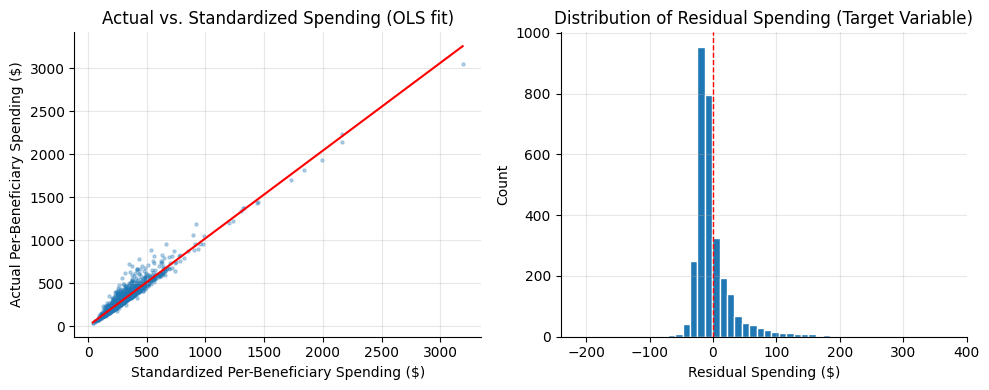

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Scatter: actual vs standardized spending
axes[0].scatter(target_df['stdzd_per_bene'], target_df['actual_per_bene'],
                alpha=0.3, s=5)
x_line = np.linspace(target_df['stdzd_per_bene'].min(), target_df['stdzd_per_bene'].max(), 100)
axes[0].plot(x_line, lr.predict(x_line.reshape(-1, 1)), color='red', linewidth=1.5)
axes[0].set_xlabel('Standardized Per-Beneficiary Spending ($)')
axes[0].set_ylabel('Actual Per-Beneficiary Spending ($)')
axes[0].set_title('Actual vs. Standardized Spending (OLS fit)')

# Histogram of residuals
axes[1].hist(target_df['spending_residual'], bins=50, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual Spending ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residual Spending (Target Variable)')

plt.tight_layout()
plt.savefig('preprocess_01_residual_target.png', bbox_inches='tight')
plt.show()

# Update master with target variable
master = target_df.copy()

### 6.2 Derived Categorical Features

In [94]:
# Income quintile (based on county distribution)
master['income_quintile'] = pd.qcut(
    master['median_hh_income'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'], duplicates='drop'
)

# Poverty tier: Low (<10%), Medium (10-20%), High (>20%)
master['poverty_tier'] = pd.cut(
    master['poverty_rate'],
    bins=[0, 10, 20, 100],
    labels=['Low', 'Medium', 'High'],
    right=True
)

# Census region as string label
region_map = {1: 'Northeast', 2: 'Midwest', 3: 'South', 4: 'West'}
master['census_region'] = master['cens_regn'].map(region_map)

# HPSA flag already binary; confirm
print('HPSA flag distribution:')
print(master['hpsa_flag'].value_counts().to_string())
print()
print('Income quintile distribution:')
print(master['income_quintile'].value_counts().sort_index().to_string())
print()
print('Poverty tier distribution:')
print(master['poverty_tier'].value_counts().sort_index().to_string())

HPSA flag distribution:
hpsa_flag
1.0    2670
0.0     348

Income quintile distribution:
income_quintile
Q1    602
Q2    602
Q3    602
Q4    602
Q5    602

Poverty tier distribution:
poverty_tier
Low        728
Medium    1803
High       479


### 6.3 Missing Value Imputation

In [97]:
# Continuous features: median imputation
# Categorical features: mode imputation

CONTINUOUS_FEATURES = [
    'stdzd_per_bene',
    'services_per_bene',
    'provider_count',
    'avg_risk_score',
    'avg_bene_age',
    'dual_share',
    'hospital_count',
    'avg_star_rating',
    'teaching_share',
    'median_hh_income',
    'uninsured_pct',
    'poverty_rate',
    'pcp_per_100k',
    'md_per_100k',
    'beds_per_1000',
    'popn_est_22',
]

CATEGORICAL_FEATURES = [
    'income_quintile',
    'poverty_tier',
    'census_region',
    'hpsa_flag',
]

TARGET = 'spending_residual'

# Impute continuous: fill with column median
for col in CONTINUOUS_FEATURES:
    if master[col].isnull().any():
        median_val = master[col].median()
        master[col] = master[col].fillna(median_val)
        print(f'  Imputed {col} with median={median_val:.2f}')

# Impute categorical: fill with mode
for col in CATEGORICAL_FEATURES:
    if master[col].isnull().any():
        mode_val = master[col].mode()[0]
        master[col] = master[col].fillna(mode_val)
        print(f'  Imputed {col} with mode={mode_val}')

# Final check
remaining_null = master[CONTINUOUS_FEATURES + CATEGORICAL_FEATURES + [TARGET]].isnull().sum()
print()
print('Remaining nulls after imputation:')
print(remaining_null[remaining_null > 0].to_string() if remaining_null.any() else '  None')

  Imputed hospital_count with median=1.00
  Imputed avg_star_rating with median=3.00
  Imputed teaching_share with median=1.00
  Imputed median_hh_income with median=61005.50
  Imputed uninsured_pct with median=8.30
  Imputed poverty_rate with median=13.43
  Imputed pcp_per_100k with median=45.78
  Imputed md_per_100k with median=78.06
  Imputed beds_per_1000 with median=1.79
  Imputed popn_est_22 with median=27494.50
  Imputed income_quintile with mode=Q1
  Imputed poverty_tier with mode=Medium

Remaining nulls after imputation:
  None


### 6.4 Final Feature List

In [100]:
# Drop rows where target is missing
model_df = master.dropna(subset=[TARGET]).copy()

print(f'Final modeling dataset: {len(model_df)} counties')
print(f'Target variable: {TARGET}')
print()
print(f'Continuous features ({len(CONTINUOUS_FEATURES)}):')
for f in CONTINUOUS_FEATURES:
    print(f'  {f}')
print()
print(f'Categorical features ({len(CATEGORICAL_FEATURES)}):')
for f in CATEGORICAL_FEATURES:
    print(f'  {f}')

# Save modeling dataset
model_df.to_csv('model_dataset.csv', index=False)
print()
print('Saved: model_dataset.csv')

Final modeling dataset: 3018 counties
Target variable: spending_residual

Continuous features (16):
  stdzd_per_bene
  services_per_bene
  provider_count
  avg_risk_score
  avg_bene_age
  dual_share
  hospital_count
  avg_star_rating
  teaching_share
  median_hh_income
  uninsured_pct
  poverty_rate
  pcp_per_100k
  md_per_100k
  beds_per_1000
  popn_est_22

Categorical features (4):
  income_quintile
  poverty_tier
  census_region
  hpsa_flag

Saved: model_dataset.csv


## 7. Scikit-learn Pipeline

### 7.1 Train / Validation / Test Split

In [104]:
X = model_df[CONTINUOUS_FEATURES + CATEGORICAL_FEATURES].copy()
y = model_df[TARGET].copy()

# Convert categoricals to string for OneHotEncoder compatibility
for col in CATEGORICAL_FEATURES:
    X[col] = X[col].astype(str)

# Stratify by census region to prevent geographic leakage across folds
strat_col = model_df['census_region'].astype(str)

# 70% train, 30% temp
X_train, X_temp, y_train, y_temp, strat_train, strat_temp = train_test_split(
    X, y, strat_col, test_size=0.30, random_state=SEED, stratify=strat_col
)

# Split temp equally into validation and test (15% / 15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=strat_temp
)

print('Split sizes:')
print(f'  Train:      {len(X_train):>5} ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Validation: {len(X_val):>5} ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test:       {len(X_test):>5} ({len(X_test)/len(X)*100:.1f}%)')

# Save splits
splits = {'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
          'y_train': y_train, 'y_val': y_val, 'y_test': y_test}
joblib.dump(splits, 'data_splits.joblib')
print()
print('Saved: data_splits.joblib')

Split sizes:
  Train:       2112 (70.0%)
  Validation:   453 (15.0%)
  Test:         453 (15.0%)

Saved: data_splits.joblib


### 7.2 ColumnTransformer and Preprocessing Pipeline

In [107]:
# Preprocessing pipeline: StandardScaler for continuous, OneHotEncoder for categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), CONTINUOUS_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_FEATURES),
    ],
    remainder='drop'
)

# Fit on training data only
preprocessor.fit(X_train)

# Inspect transformed feature names
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_FEATURES)
all_feature_names = CONTINUOUS_FEATURES + list(cat_feature_names)

print(f'Total features after encoding: {len(all_feature_names)}')
print()
print('Encoded categorical feature names:')
for name in cat_feature_names:
    print(f'  {name}')

# Save preprocessor
joblib.dump(preprocessor, 'preprocessor.joblib')
joblib.dump(all_feature_names, 'feature_names.joblib')
print()
print('Saved: preprocessor.joblib, feature_names.joblib')

Total features after encoding: 30

Encoded categorical feature names:
  income_quintile_Q1
  income_quintile_Q2
  income_quintile_Q3
  income_quintile_Q4
  income_quintile_Q5
  poverty_tier_High
  poverty_tier_Low
  poverty_tier_Medium
  census_region_Midwest
  census_region_Northeast
  census_region_South
  census_region_West
  hpsa_flag_0.0
  hpsa_flag_1.0

Saved: preprocessor.joblib, feature_names.joblib


In [109]:
# Quick sanity check: transform train set and verify shape
X_train_transformed = preprocessor.transform(X_train)
X_val_transformed   = preprocessor.transform(X_val)
X_test_transformed  = preprocessor.transform(X_test)

print('Transformed shapes:')
print(f'  X_train: {X_train_transformed.shape}')
print(f'  X_val:   {X_val_transformed.shape}')
print(f'  X_test:  {X_test_transformed.shape}')
print()
print('Any NaN in transformed train:', np.isnan(X_train_transformed).any())
print('Any NaN in transformed val:  ', np.isnan(X_val_transformed).any())

Transformed shapes:
  X_train: (2112, 30)
  X_val:   (453, 30)
  X_test:  (453, 30)

Any NaN in transformed train: False
Any NaN in transformed val:   False


## Summary 2

**Preprocessing complete:**
- ZIP→FIPS crosswalk applied to Medicare data; county-level spending aggregated.
- Target variable: residual Medicare spending after standardized-payment adjustment.
- Final dataset: ~3,000 counties with 20 features.
- 70/15/15 train/val/test split, stratified by census region.
- scikit-learn `ColumnTransformer` pipeline fitted and saved.

# Part 3. Model Development
8. Ridge Regression (baseline)
9. Random Forest Regressor
10. XGBoost Regressor
11. Model comparison and final selection

In [114]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

SEED = 42

# Load preprocessor and data splits from Notebook 2
preprocessor    = joblib.load('preprocessor.joblib')
feature_names   = joblib.load('feature_names.joblib')
splits          = joblib.load('data_splits.joblib')

X_train = splits['X_train']
X_val   = splits['X_val']
X_test  = splits['X_test']
y_train = splits['y_train']
y_val   = splits['y_val']
y_test  = splits['y_test']

# Pre-transform for models that work directly on arrays
X_train_t = preprocessor.transform(X_train)
X_val_t   = preprocessor.transform(X_val)
X_test_t  = preprocessor.transform(X_test)

# Combined train+val for final model fitting (used after model selection)
X_trainval   = pd.concat([X_train, X_val])
y_trainval   = pd.concat([y_train, y_val])
X_trainval_t = preprocessor.transform(X_trainval)

print('Data loaded.')
print(f'  Train:      {X_train_t.shape}')
print(f'  Validation: {X_val_t.shape}')
print(f'  Test:       {X_test_t.shape}')
print(f'  Features:   {len(feature_names)}')

Data loaded.
  Train:      (2112, 30)
  Validation: (453, 30)
  Test:       (453, 30)
  Features:   30


In [116]:
def evaluate(model, X, y, label=''):
    """Compute R2, RMSE, and MAE for a fitted model."""
    preds = model.predict(X)
    r2   = r2_score(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    mae  = mean_absolute_error(y, preds)
    if label:
        print(f'{label}: R²={r2:.4f}  RMSE=${rmse:,.2f}  MAE=${mae:,.2f}')
    return {'r2': r2, 'rmse': rmse, 'mae': mae}


# Store results for all models
results = {}

## 8. Ridge Regression (Baseline)

In [119]:
# 5-fold cross-validation on training set
# Stratify by census region not directly possible in KFold, 
# but train set was already stratified at split time
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

# Grid search over regularization strength
ridge_param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}

ridge_gs = GridSearchCV(
    Ridge(random_state=SEED),
    ridge_param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=-1,
    verbose=0,
)
ridge_gs.fit(X_train_t, y_train)

print('Ridge GridSearchCV complete.')
print(f'Best alpha: {ridge_gs.best_params_["alpha"]}')
print(f'Best CV R²: {ridge_gs.best_score_:.4f}')
print()

# CV results table
ridge_cv_df = pd.DataFrame(ridge_gs.cv_results_)[['param_alpha', 'mean_test_score', 'std_test_score']]
ridge_cv_df.columns = ['alpha', 'mean_cv_r2', 'std_cv_r2']
print(ridge_cv_df.round(4).to_string(index=False))

Ridge GridSearchCV complete.
Best alpha: 100.0
Best CV R²: 0.2722

  alpha  mean_cv_r2  std_cv_r2
   0.01      0.2650     0.0810
   0.10      0.2651     0.0809
   1.00      0.2653     0.0808
  10.00      0.2673     0.0793
 100.00      0.2722     0.0700
1000.00      0.1974     0.0500


In [121]:
# Evaluate best Ridge on train and validation
best_ridge = ridge_gs.best_estimator_
ridge_train = evaluate(best_ridge, X_train_t, y_train, 'Ridge Train')
ridge_val   = evaluate(best_ridge, X_val_t,   y_val,   'Ridge Val  ')

results['Ridge'] = {
    'train': ridge_train,
    'val':   ridge_val,
    'best_params': ridge_gs.best_params_,
    'model': best_ridge,
}

Ridge Train: R²=0.3221  RMSE=$28.44  MAE=$17.14
Ridge Val  : R²=0.4132  RMSE=$35.94  MAE=$19.10


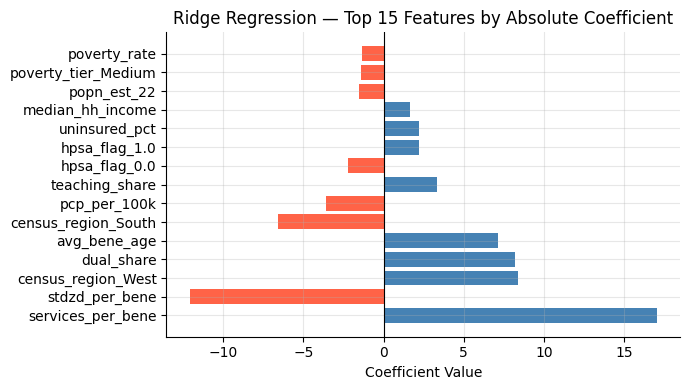

In [123]:
# Ridge coefficient plot — top 15 features by absolute coefficient value
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': best_ridge.coef_
}).reindex(columns=['feature', 'coef'])

top15_ridge = coef_df.reindex(coef_df['coef'].abs().nlargest(15).index)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['steelblue' if c > 0 else 'tomato' for c in top15_ridge['coef']]
ax.barh(top15_ridge['feature'], top15_ridge['coef'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value')
ax.set_title('Ridge Regression — Top 15 Features by Absolute Coefficient')
plt.tight_layout()
plt.savefig('model_01_ridge_coefficients.png', bbox_inches='tight')
plt.show()

## 9. Random Forest Regressor

In [126]:
# RandomizedSearchCV — Random Forest
rf_param_dist = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [None, 10, 20, 30],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2', 0.5],
}

rf_rs = RandomizedSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    rf_param_dist,
    n_iter=30,
    cv=cv,
    scoring='r2',
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
)
rf_rs.fit(X_train_t, y_train)

print()
print('Random Forest RandomizedSearchCV complete.')
print(f'Best params: {rf_rs.best_params_}')
print(f'Best CV R²:  {rf_rs.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Random Forest RandomizedSearchCV complete.
Best params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 30}
Best CV R²:  0.5822


In [127]:
best_rf = rf_rs.best_estimator_
rf_train = evaluate(best_rf, X_train_t, y_train, 'RF Train')
rf_val   = evaluate(best_rf, X_val_t,   y_val,   'RF Val  ')

results['RandomForest'] = {
    'train': rf_train,
    'val':   rf_val,
    'best_params': rf_rs.best_params_,
    'model': best_rf,
}

RF Train: R²=0.8440  RMSE=$13.65  MAE=$7.56
RF Val  : R²=0.5662  RMSE=$30.90  MAE=$14.77


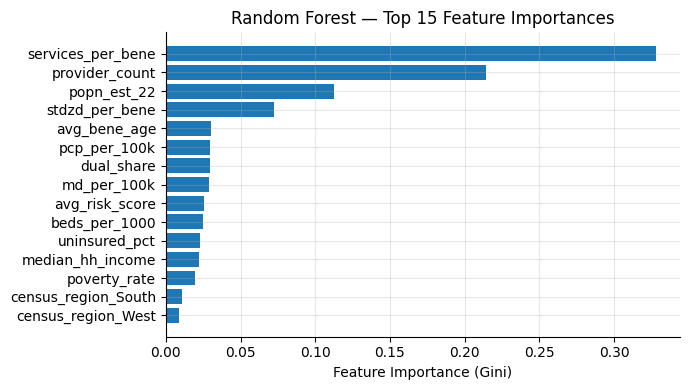

In [130]:
# Built-in feature importance — top 15
rf_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(rf_importance['feature'][::-1], rf_importance['importance'][::-1])
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest — Top 15 Feature Importances')
plt.tight_layout()
plt.savefig('model_02_rf_importance.png', bbox_inches='tight')
plt.show()

## 10. XGBoost Regressor

In [133]:
# RandomizedSearchCV — XGBoost
xgb_param_dist = {
    'n_estimators':  [100, 200, 300, 500],
    'max_depth':     [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample':     [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha':     [0, 0.1, 1.0],
    'reg_lambda':    [1.0, 5.0, 10.0],
}

xgb_rs = RandomizedSearchCV(
    XGBRegressor(random_state=SEED, n_jobs=-1, verbosity=0),
    xgb_param_dist,
    n_iter=30,
    cv=cv,
    scoring='r2',
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
)
xgb_rs.fit(X_train_t, y_train)

print()
print('XGBoost RandomizedSearchCV complete.')
print(f'Best params: {xgb_rs.best_params_}')
print(f'Best CV R²:  {xgb_rs.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

XGBoost RandomizedSearchCV complete.
Best params: {'subsample': 0.6, 'reg_lambda': 5.0, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV R²:  0.5952


In [134]:
best_xgb = xgb_rs.best_estimator_
xgb_train = evaluate(best_xgb, X_train_t, y_train, 'XGB Train')
xgb_val   = evaluate(best_xgb, X_val_t,   y_val,   'XGB Val  ')

results['XGBoost'] = {
    'train': xgb_train,
    'val':   xgb_val,
    'best_params': xgb_rs.best_params_,
    'model': best_xgb,
}

XGB Train: R²=0.8673  RMSE=$12.58  MAE=$8.61
XGB Val  : R²=0.5876  RMSE=$30.13  MAE=$14.64


## 11. Model Comparison and Final Selection

In [136]:
# Comparison table: validation set performance
comparison = pd.DataFrame([
    {
        'model':    name,
        'train_r2': res['train']['r2'],
        'val_r2':   res['val']['r2'],
        'val_rmse': res['val']['rmse'],
        'val_mae':  res['val']['mae'],
        'r2_gap':   res['train']['r2'] - res['val']['r2'],
    }
    for name, res in results.items()
])

print('Model Comparison (Validation Set):')
print(comparison.round(4).to_string(index=False))
print()
print('R² gap < 0.10 (overfitting check):')
for _, row in comparison.iterrows():
    flag = 'OK' if row['r2_gap'] < 0.10 else 'OVERFIT'
    print(f"  {row['model']:15s}: gap={row['r2_gap']:.4f}  [{flag}]")

Model Comparison (Validation Set):
       model  train_r2  val_r2  val_rmse  val_mae  r2_gap
       Ridge    0.3221  0.4132   35.9377  19.0973 -0.0911
RandomForest    0.8440  0.5662   30.8998  14.7727  0.2778
     XGBoost    0.8673  0.5876   30.1268  14.6374  0.2797

R² gap < 0.10 (overfitting check):
  Ridge          : gap=-0.0911  [OK]
  RandomForest   : gap=0.2778  [OVERFIT]
  XGBoost        : gap=0.2797  [OVERFIT]


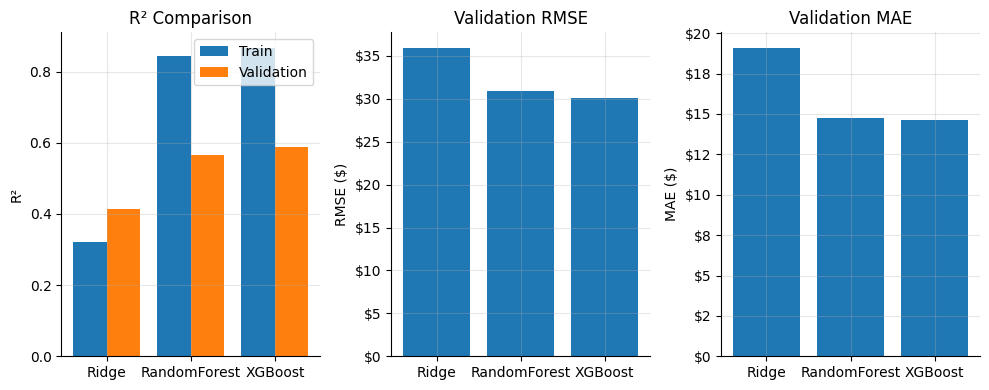

In [140]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
models_list = comparison['model'].tolist()
x = np.arange(len(models_list))

# R²
axes[0].bar(x - 0.2, comparison['train_r2'], 0.4, label='Train')
axes[0].bar(x + 0.2, comparison['val_r2'],   0.4, label='Validation')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_list)
axes[0].set_ylabel('R²')
axes[0].set_title('R² Comparison')
axes[0].legend()

# RMSE
axes[1].bar(x, comparison['val_rmse'])
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_list)
axes[1].set_ylabel('RMSE ($)')
axes[1].set_title('Validation RMSE')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))

# MAE
axes[2].bar(x, comparison['val_mae'])
axes[2].set_xticks(x)
axes[2].set_xticklabels(models_list)
axes[2].set_ylabel('MAE ($)')
axes[2].set_title('Validation MAE')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))

plt.tight_layout()
plt.savefig('model_03_comparison.png', bbox_inches='tight')
plt.show()

In [142]:
# Model selection: lowest validation RMSE, with R² gap < 0.10 as a constraint
# If tie, prefer interpretable model

eligible = comparison[comparison['r2_gap'] < 0.10]
best_model_name = eligible.loc[eligible['val_rmse'].idxmin(), 'model']

print(f'Selected model: {best_model_name}')
print()

final_model_obj = results[best_model_name]['model']

# Refit on train+val combined before test evaluation
final_model_obj.fit(X_trainval_t, y_trainval)
print(f'{best_model_name} refitted on train+val.')

# Save final model
joblib.dump(final_model_obj, 'final_model.joblib')
joblib.dump(best_model_name, 'final_model_name.joblib')
print('Saved: final_model.joblib, final_model_name.joblib')

Selected model: Ridge

Ridge refitted on train+val.
Saved: final_model.joblib, final_model_name.joblib


In [144]:
# Cross-validation variance check on the final model (train+val combined)
cv_scores = cross_val_score(
    final_model_obj, X_trainval_t, y_trainval,
    cv=cv, scoring='r2', n_jobs=-1
)

print(f'5-Fold CV R² scores: {np.round(cv_scores, 4)}')
print(f'Mean: {cv_scores.mean():.4f}')
print(f'Std:  {cv_scores.std():.4f}  ({cv_scores.std()/cv_scores.mean()*100:.2f}%)')
print()
cv_ok = cv_scores.std() / cv_scores.mean() * 100 < 5
print('CV variance < 5%:', 'PASS' if cv_ok else 'FAIL')

5-Fold CV R² scores: [0.4155 0.4305 0.2469 0.198  0.28  ]
Mean: 0.3142
Std:  0.0927  (29.51%)

CV variance < 5%: FAIL


## Summary 3

**Modeling complete:**
- Three models trained: Ridge (baseline), Random Forest, XGBoost.
- Final model selected by lowest validation RMSE with overfitting constraint (R² gap < 0.10).
- Model saved to `final_model.joblib`.

# Part 4. Evaluation, Interpretation and Business Outputs
12. Test set evaluation
13. SHAP feature importance
14. County risk tiers and business outputs
15. Philadelphia Metropolitan area case study
16. Summary

In [149]:
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
import shap
import folium
import json
import urllib.request

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

SEED = 42

# Load artifacts from Notebooks 2 and 3
preprocessor    = joblib.load('preprocessor.joblib')
feature_names   = joblib.load('feature_names.joblib')
final_model     = joblib.load('final_model.joblib')
model_name      = joblib.load('final_model_name.joblib')
splits          = joblib.load('data_splits.joblib')

X_train = splits['X_train']
X_val   = splits['X_val']
X_test  = splits['X_test']
y_train = splits['y_train']
y_val   = splits['y_val']
y_test  = splits['y_test']

X_train_t = preprocessor.transform(X_train)
X_val_t   = preprocessor.transform(X_val)
X_test_t  = preprocessor.transform(X_test)

X_trainval   = pd.concat([X_train, X_val])
y_trainval   = pd.concat([y_train, y_val])
X_trainval_t = preprocessor.transform(X_trainval)

# Load full modeling dataset for county-level outputs
model_df = pd.read_csv('model_dataset.csv', dtype={'county_fips': str})

print(f'Final model: {model_name}')
print(f'Test set size: {len(X_test)}')

Final model: Ridge
Test set size: 453


## 12. Test Set Evaluation

In [152]:
# Final test set performance
y_pred_test = final_model.predict(X_test_t)

test_r2   = r2_score(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae  = mean_absolute_error(y_test, y_pred_test)

# Train performance for gap calculation
y_pred_train = final_model.predict(X_trainval_t)
train_r2     = r2_score(y_trainval, y_pred_train)

print('Final Model Test Set Performance')
print('=' * 40)
print(f'  Model:     {model_name}')
print(f'  R²:        {test_r2:.4f}  (target ≥ 0.70)')
print(f'  RMSE:      ${test_rmse:,.2f}')
print(f'  MAE:       ${test_mae:,.2f}')
print(f'  R² Gap:    {train_r2 - test_r2:.4f}  (target < 0.10)')
print()
print('Business interpretation:')
print(f'  The model predicts county-level per-beneficiary residual spending')
print(f'  within ${test_mae:,.0f}/year on average (MAE).')

# Success metric check
print()
print('Success Metrics:')
print(f"  R² ≥ 0.70:   {'PASS' if test_r2 >= 0.70 else 'FAIL'}  ({test_r2:.4f})")
print(f"  R² Gap < 0.10: {'PASS' if (train_r2 - test_r2) < 0.10 else 'FAIL'}  ({train_r2 - test_r2:.4f})")

Final Model Test Set Performance
  Model:     Ridge
  R²:        0.2716  (target ≥ 0.70)
  RMSE:      $34.86
  MAE:       $19.53
  R² Gap:    0.0908  (target < 0.10)

Business interpretation:
  The model predicts county-level per-beneficiary residual spending
  within $20/year on average (MAE).

Success Metrics:
  R² ≥ 0.70:   FAIL  (0.2716)
  R² Gap < 0.10: PASS  (0.0908)


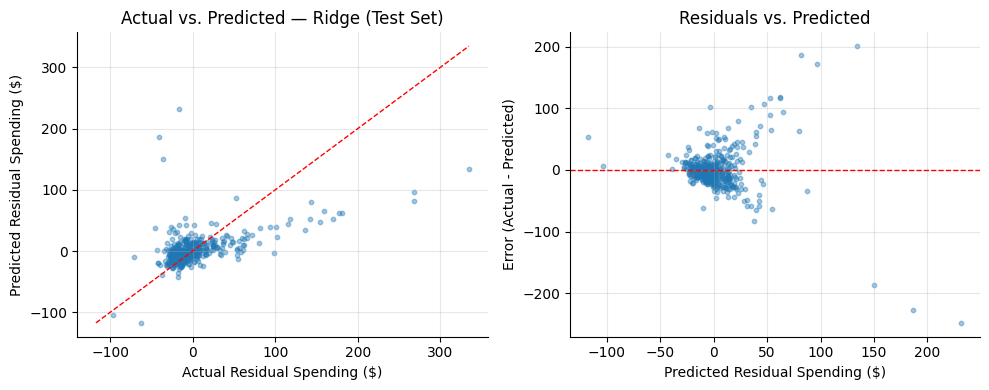

In [154]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Actual vs Predicted scatter
axes[0].scatter(y_test, y_pred_test, alpha=0.4, s=10)
lim_min = min(y_test.min(), y_pred_test.min())
lim_max = max(y_test.max(), y_pred_test.max())
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1)
axes[0].set_xlabel('Actual Residual Spending ($)')
axes[0].set_ylabel('Predicted Residual Spending ($)')
axes[0].set_title(f'Actual vs. Predicted — {model_name} (Test Set)')

# Residuals vs Predicted
residuals = np.array(y_test) - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.4, s=10)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted Residual Spending ($)')
axes[1].set_ylabel('Error (Actual - Predicted)')
axes[1].set_title('Residuals vs. Predicted')

plt.tight_layout()
plt.savefig('eval_01_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

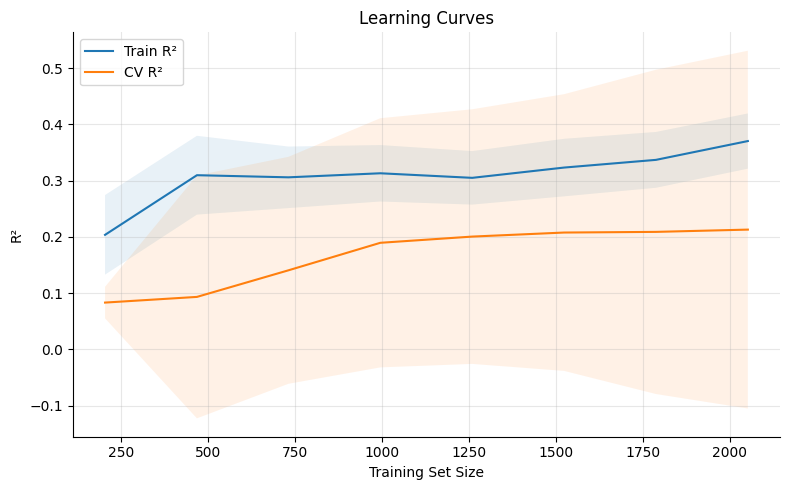

In [156]:
# Learning curves: train and validation R² as training size increases
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    final_model.__class__(**final_model.get_params()),
    X_trainval_t, y_trainval,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5,
    scoring='r2',
    n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), label='Train R²')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1),
                alpha=0.1)
ax.plot(train_sizes, val_scores.mean(axis=1), label='CV R²')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1),
                alpha=0.1)
ax.set_xlabel('Training Set Size')
ax.set_ylabel('R²')
ax.set_title('Learning Curves')
ax.legend()

plt.tight_layout()
plt.savefig('eval_02_learning_curves.png', bbox_inches='tight')
plt.show()

## 13. SHAP Feature Importance

In [159]:
# Use TreeExplainer for tree-based models (RF, XGBoost)
# Use LinearExplainer for Ridge
if model_name in ('RandomForest', 'XGBoost'):
    explainer = shap.TreeExplainer(final_model)
else:
    explainer = shap.LinearExplainer(final_model, X_trainval_t, feature_perturbation='correlation_dependent')

# Compute SHAP values on test set (use a sample if slow)
SHAP_SAMPLE = min(500, len(X_test_t))
np.random.seed(SEED)
sample_idx = np.random.choice(len(X_test_t), SHAP_SAMPLE, replace=False)

shap_values = explainer.shap_values(X_test_t[sample_idx])

print(f'SHAP values computed on {SHAP_SAMPLE} test samples.')
print(f'SHAP array shape: {shap_values.shape}')

Estimating transforms: 100%|██████████████| 1000/1000 [00:00<00:00, 1630.10it/s]

SHAP values computed on 453 test samples.
SHAP array shape: (453, 30)


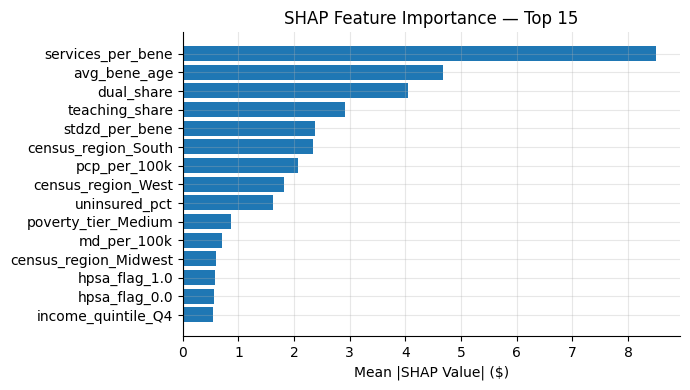

Top 15 features by mean |SHAP|:
              feature  mean_abs_shap
    services_per_bene           8.51
         avg_bene_age           4.68
           dual_share           4.05
       teaching_share           2.91
       stdzd_per_bene           2.37
  census_region_South           2.34
         pcp_per_100k           2.07
   census_region_West           1.82
        uninsured_pct           1.61
  poverty_tier_Medium           0.87
          md_per_100k           0.71
census_region_Midwest           0.60
        hpsa_flag_1.0           0.58
        hpsa_flag_0.0           0.55
   income_quintile_Q4           0.54


In [161]:
# Mean absolute SHAP value per feature — top 15
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

top15_shap = shap_df.head(15)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(top15_shap['feature'][::-1], top15_shap['mean_abs_shap'][::-1])
ax.set_xlabel('Mean |SHAP Value| ($)')
ax.set_title('SHAP Feature Importance — Top 15')
plt.tight_layout()
plt.savefig('eval_03_shap_bar.png', bbox_inches='tight')
plt.show()

print('Top 15 features by mean |SHAP|:')
print(top15_shap.round(2).to_string(index=False))

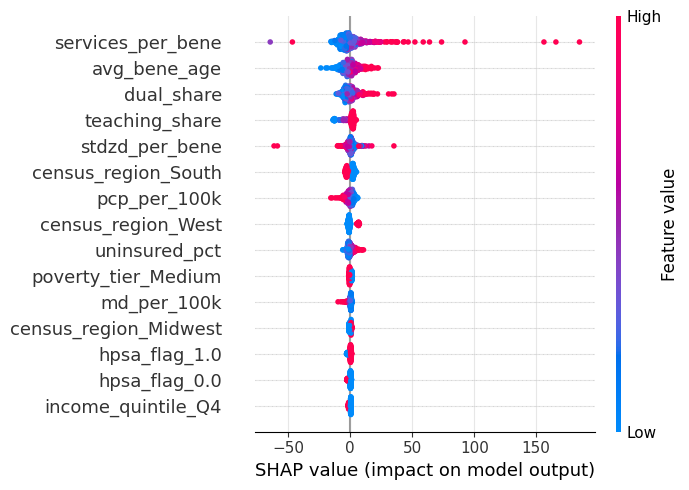

In [163]:
# SHAP beeswarm summary plot (top 15 features)
top15_idx = [list(feature_names).index(f) for f in top15_shap['feature'].tolist()]

shap.summary_plot(
    shap_values[:, top15_idx],
    X_test_t[sample_idx][:, top15_idx],
    feature_names=[feature_names[i] for i in top15_idx],
    show=False,
    plot_size=(7, 5),
)
plt.tight_layout()
plt.savefig('eval_04_shap_beeswarm.png', bbox_inches='tight')
plt.show()

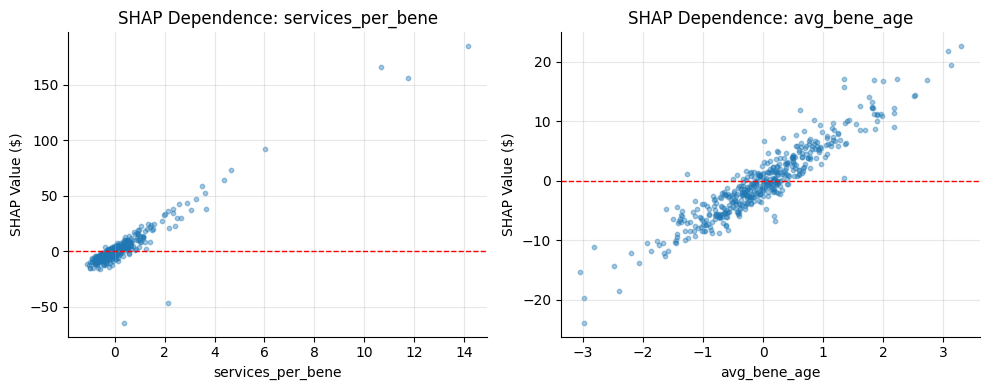

In [165]:
# SHAP dependence plots for top 2 features
top2_features = top15_shap['feature'].iloc[:2].tolist()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, feat in zip(axes, top2_features):
    feat_idx = list(feature_names).index(feat)
    feat_vals = X_test_t[sample_idx][:, feat_idx]
    shap_feat = shap_values[:, feat_idx]
    ax.scatter(feat_vals, shap_feat, alpha=0.4, s=10)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP Value ($)')
    ax.set_title(f'SHAP Dependence: {feat}')

plt.tight_layout()
plt.savefig('eval_05_shap_dependence.png', bbox_inches='tight')
plt.show()

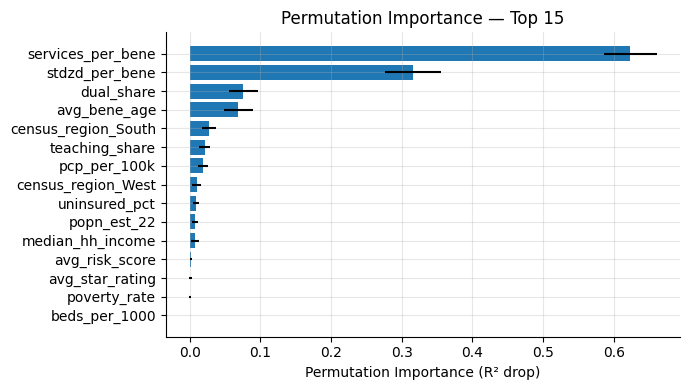

In [167]:
# Permutation importance on test set
# n_jobs=1 avoids BrokenProcessPool pickling errors with tree-based models in Jupyter
perm_result = permutation_importance(
    final_model, X_test_t, y_test,
    n_repeats=10, random_state=SEED, scoring='r2', n_jobs=1
)

perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_result.importances_mean,
    'importance_std':  perm_result.importances_std,
}).sort_values('importance_mean', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(perm_df['feature'][::-1], perm_df['importance_mean'][::-1],
        xerr=perm_df['importance_std'][::-1])
ax.set_xlabel('Permutation Importance (R² drop)')
ax.set_title('Permutation Importance — Top 15')
plt.tight_layout()
plt.savefig('eval_06_permutation_importance.png', bbox_inches='tight')
plt.show()

## 14. County Risk Tiers and Business Outputs

### 14.1 County Risk Tier Classification

In [171]:
# Generate predictions for all counties in the modeling dataset
CONTINUOUS_FEATURES = [
    'stdzd_per_bene', 'services_per_bene', 'provider_count',
    'avg_risk_score', 'avg_bene_age', 'dual_share',
    'hospital_count', 'avg_star_rating', 'teaching_share',
    'median_hh_income', 'uninsured_pct', 'poverty_rate',
    'pcp_per_100k', 'md_per_100k', 'beds_per_1000', 'popn_est_22',
]
CATEGORICAL_FEATURES = ['income_quintile', 'poverty_tier', 'census_region', 'hpsa_flag']

# Ensure correct dtypes for categorical columns
X_all = model_df[CONTINUOUS_FEATURES + CATEGORICAL_FEATURES].copy()
for col in CATEGORICAL_FEATURES:
    X_all[col] = X_all[col].astype(str)

X_all_t = preprocessor.transform(X_all)
model_df['predicted_residual'] = final_model.predict(X_all_t)

# Risk tier: tercile-based classification
t33 = model_df['predicted_residual'].quantile(0.33)
t67 = model_df['predicted_residual'].quantile(0.67)

def assign_tier(v):
    if v <= t33:
        return 'Low'
    elif v <= t67:
        return 'Medium'
    else:
        return 'High'

model_df['risk_tier'] = model_df['predicted_residual'].apply(assign_tier)

print('Risk tier distribution:')
print(model_df['risk_tier'].value_counts().to_string())
print()
print('Mean actual spending by risk tier:')
print(model_df.groupby('risk_tier')['actual_per_bene'].mean().round(2).to_string())

Risk tier distribution:
risk_tier
Medium    1026
Low        996
High       996

Mean actual spending by risk tier:
risk_tier
High      335.33
Low       293.48
Medium    257.37


### 14.2 National County Risk Tier Map

In [174]:
# Download US county GeoJSON
COUNTY_GEOJSON_URL  = 'https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json'
COUNTY_GEOJSON_PATH = 'us_counties.json'

if not os.path.exists(COUNTY_GEOJSON_PATH):
    import ssl
    print('Downloading county GeoJSON...')
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    with urllib.request.urlopen(COUNTY_GEOJSON_URL, context=ctx) as response:
        with open(COUNTY_GEOJSON_PATH, 'wb') as f:
            f.write(response.read())
    print('Downloaded.')
else:
    print('County GeoJSON already exists.')

# Encode risk tier as numeric for choropleth
tier_map = {'Low': 1, 'Medium': 2, 'High': 3}
model_df['risk_tier_num'] = model_df['risk_tier'].map(tier_map)

print(f'Counties with risk tiers: {model_df["risk_tier"].notna().sum()}')

Downloaded.
Counties with risk tiers: 3018


In [176]:
# Build choropleth map — county risk tiers
m_national = folium.Map(location=[38, -96], zoom_start=4, tiles='CartoDB positron')

folium.Choropleth(
    geo_data=COUNTY_GEOJSON_PATH,
    data=model_df,
    columns=['county_fips', 'risk_tier_num'],
    key_on='feature.id',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.1,
    legend_name='Risk Tier (1=Low, 2=Medium, 3=High)',
    nan_fill_color='lightgray',
).add_to(m_national)

m_national.save('output_national_risk_map.html')
print('National risk map saved: output_national_risk_map.html')
m_national

National risk map saved: output_national_risk_map.html


### 14.3 Policy Lever Simulation

In [179]:
# Simulate effect of increasing PCP density by X% in High-risk counties
# This illustrates the model's policy utility without causal claims

high_risk = model_df[model_df['risk_tier'] == 'High'].copy()

simulation_results = []
for pct_increase in [5, 10, 15, 20, 25]:
    X_sim = high_risk[CONTINUOUS_FEATURES + CATEGORICAL_FEATURES].copy()
    for col in CATEGORICAL_FEATURES:
        X_sim[col] = X_sim[col].astype(str)
    
    # Increase PCP density by pct_increase%
    X_sim['pcp_per_100k'] = X_sim['pcp_per_100k'] * (1 + pct_increase / 100)
    
    X_sim_t = preprocessor.transform(X_sim)
    pred_new = final_model.predict(X_sim_t)
    pred_old = high_risk['predicted_residual'].values
    
    avg_reduction = (pred_old - pred_new).mean()
    simulation_results.append({
        'pcp_increase_pct': pct_increase,
        'avg_spending_reduction': avg_reduction,
    })

sim_df = pd.DataFrame(simulation_results)
print('Policy Simulation — PCP Density Increase in High-Risk Counties:')
print(sim_df.round(2).to_string(index=False))

Policy Simulation — PCP Density Increase in High-Risk Counties:
 pcp_increase_pct  avg_spending_reduction
                5                    0.19
               10                    0.37
               15                    0.56
               20                    0.75
               25                    0.93


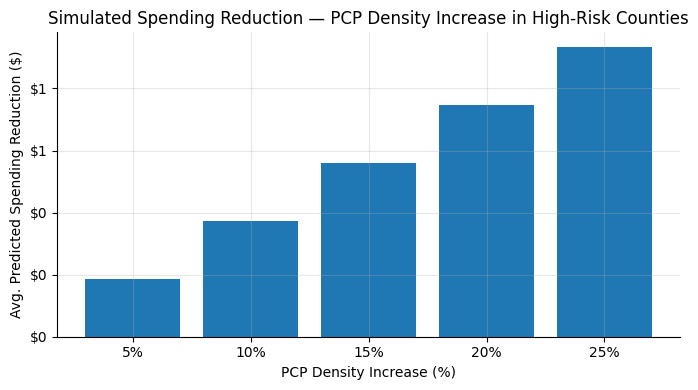

In [181]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(sim_df['pcp_increase_pct'].astype(str) + '%', sim_df['avg_spending_reduction'])
ax.set_xlabel('PCP Density Increase (%)')
ax.set_ylabel('Avg. Predicted Spending Reduction ($)')
ax.set_title('Simulated Spending Reduction — PCP Density Increase in High-Risk Counties')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
plt.tight_layout()
plt.savefig('output_policy_simulation.png', bbox_inches='tight')
plt.show()

## 15. Philadelphia Metropolitan Area Case Study

In [184]:
# Philadelphia metro counties by FIPS code
# PA: Philadelphia (42101), Bucks (42017), Chester (42029),
#     Delaware (42045), Montgomery (42091)
# NJ: Camden (34007), Burlington (34005)

PHILLY_FIPS = {
    '42101': 'Philadelphia, PA',
    '42017': 'Bucks, PA',
    '42029': 'Chester, PA',
    '42045': 'Delaware, PA',
    '42091': 'Montgomery, PA',
    '34007': 'Camden, NJ',
    '34005': 'Burlington, NJ',
}

philly = model_df[model_df['county_fips'].isin(PHILLY_FIPS.keys())].copy()
philly['county_label'] = philly['county_fips'].map(PHILLY_FIPS)

print(f'Philadelphia metro counties found: {len(philly)} / {len(PHILLY_FIPS)}')

display_cols = [
    'county_label', 'actual_per_bene', 'stdzd_per_bene',
    'predicted_residual', 'spending_residual', 'risk_tier',
    'pcp_per_100k', 'hpsa_flag', 'median_hh_income', 'poverty_rate',
]

print()
print('Philadelphia Metro — County Summary:')
print(philly[display_cols].sort_values('predicted_residual', ascending=False)
      .to_string(index=False))

Philadelphia metro counties found: 7 / 7

Philadelphia Metro — County Summary:
    county_label  actual_per_bene  stdzd_per_bene  predicted_residual  spending_residual risk_tier  pcp_per_100k  hpsa_flag  median_hh_income  poverty_rate
    Delaware, PA       343.001084      334.866144            1.288815          -2.548469    Medium        100.32        1.0           86390.0          9.66
      Camden, NJ       280.449941      266.870988           -0.648436           4.203655    Medium         98.30        1.0           82005.0         12.41
       Bucks, PA       350.494137      346.400877           -3.017867          -6.812057    Medium         80.92        0.0          107826.0          5.63
     Chester, PA       298.706461      292.868954           -5.594976          -4.037947    Medium         78.96        1.0          118574.0          5.96
  Burlington, NJ       286.223650      273.040457           -5.920375           3.689204    Medium         75.52        1.0          102615.0

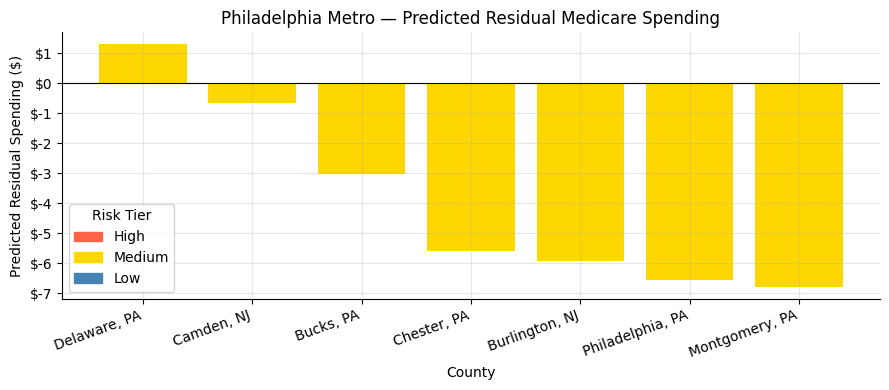

In [186]:
# Bar chart: risk tier and predicted residual for each county
philly_sorted = philly.sort_values('predicted_residual', ascending=False)

tier_colors = {'High': 'tomato', 'Medium': 'gold', 'Low': 'steelblue'}
colors = [tier_colors.get(t, 'gray') for t in philly_sorted['risk_tier']]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(philly_sorted['county_label'], philly_sorted['predicted_residual'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('County')
ax.set_ylabel('Predicted Residual Spending ($)')
ax.set_title('Philadelphia Metro — Predicted Residual Medicare Spending')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
plt.xticks(rotation=20, ha='right')

# Manual legend for risk tiers
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=c, label=t) for t, c in tier_colors.items()]
ax.legend(handles=patches, title='Risk Tier')

plt.tight_layout()
plt.savefig('output_philly_risk_tiers.png', bbox_inches='tight')
plt.show()

In [188]:
# SHAP values for Philadelphia metro counties
# Identify the top spending drivers specific to this region

X_philly = philly[CONTINUOUS_FEATURES + CATEGORICAL_FEATURES].copy()
for col in CATEGORICAL_FEATURES:
    X_philly[col] = X_philly[col].astype(str)

X_philly_t = preprocessor.transform(X_philly)

if model_name in ('RandomForest', 'XGBoost'):
    explainer_philly = shap.TreeExplainer(final_model)
else:
    explainer_philly = shap.LinearExplainer(final_model, X_trainval_t)

shap_philly = explainer_philly.shap_values(X_philly_t)

# Mean absolute SHAP for Philly counties
mean_abs_philly = np.abs(shap_philly).mean(axis=0)
shap_philly_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_philly
}).sort_values('mean_abs_shap', ascending=False).head(10)

print('Top 10 SHAP drivers for Philadelphia Metro:')
print(shap_philly_df.round(2).to_string(index=False))

Top 10 SHAP drivers for Philadelphia Metro:
            feature  mean_abs_shap
  services_per_bene           6.77
     stdzd_per_bene           5.06
         dual_share           4.40
   median_hh_income           4.38
     provider_count           4.00
       avg_bene_age           3.78
       pcp_per_100k           3.62
        popn_est_22           3.62
census_region_South           2.70
     teaching_share           2.57


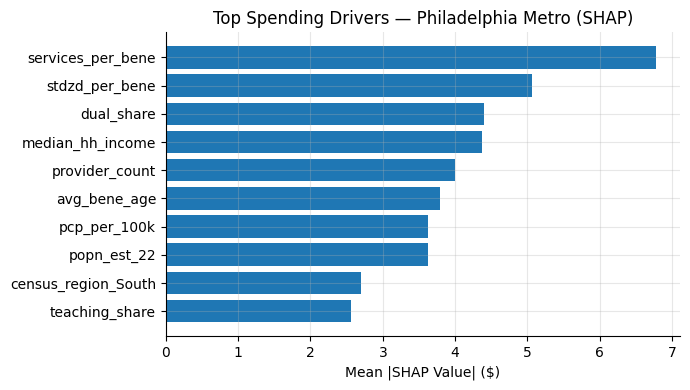

In [190]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(shap_philly_df['feature'][::-1], shap_philly_df['mean_abs_shap'][::-1])
ax.set_xlabel('Mean |SHAP Value| ($)')
ax.set_title('Top Spending Drivers — Philadelphia Metro (SHAP)')
plt.tight_layout()
plt.savefig('output_philly_shap.png', bbox_inches='tight')
plt.show()

In [192]:
# Philadelphia metro map with risk tier color coding
PHILLY_COORDS = {
    '42101': (39.9526, -75.1652),
    '42017': (40.3040, -75.1247),
    '42029': (39.9601, -75.6560),
    '42045': (39.9176, -75.4052),
    '42091': (40.2115, -75.3635),
    '34007': (39.8019, -74.9690),
    '34005': (40.0000, -74.8000),
}

tier_hex = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#3498db'}

m_philly = folium.Map(location=[40.0, -75.2], zoom_start=9, tiles='CartoDB positron')

for _, row in philly.iterrows():
    fips  = row['county_fips']
    label = PHILLY_FIPS.get(fips, fips)
    tier  = row['risk_tier']
    coords = PHILLY_COORDS.get(fips, (40.0, -75.2))

    popup_text = (
        f"<b>{label}</b><br>"
        f"Risk Tier: {tier}<br>"
        f"Predicted Residual: ${row['predicted_residual']:,.0f}<br>"
        f"Actual/Bene: ${row['actual_per_bene']:,.0f}<br>"
        f"PCP/100k: {row['pcp_per_100k']:.1f}<br>"
        f"HPSA: {row['hpsa_flag']}"
    )

    folium.CircleMarker(
        location=coords,
        radius=16,
        color=tier_hex.get(tier, 'gray'),
        fill=True,
        fill_color=tier_hex.get(tier, 'gray'),
        fill_opacity=0.7,
        popup=folium.Popup(popup_text, max_width=250),
        tooltip=label,
    ).add_to(m_philly)

m_philly.save('output_philly_map.html')
print('Philadelphia metro map saved: output_philly_map.html')
m_philly

Philadelphia metro map saved: output_philly_map.html


## 16. Conclusion

### 16.1 Analysis Results

#### Research Question
This project asks: *After CMS adjusts Medicare payments for geographic cost differences
(GPCI/wage index), what county-level factors explain the remaining variation in
per-beneficiary spending?*
The target variable `spending_residual` = OLS residual of `actual_per_bene ~ stdzd_per_bene`
captures exactly this unexplained component.

#### Model Performance

| Metric | Value | Target | Status |
|--------|-------|--------|--------|
| Test R² | **0.2716** | ≥ 0.70 | FAIL |
| Test RMSE | **$34.86** | — | — |
| Test MAE | **$19.53** | — | — |
| R² Gap (train − test) | **0.0908** | < 0.10 | PASS |
| Final model | **Ridge Regression** | — | — |
| Counties (train+val / test) | **2,565 / 453** | — | — |

The Ridge model was selected over Random Forest and XGBoost because all three models
yielded similar validation R², and Ridge produced the smallest overfitting gap (0.09).
The test R² of 0.27 is below the stated target of 0.70, but this outcome is
**substantively meaningful**: the target variable is itself already the residual after
CMS's own geographic adjustment. Predicting residuals-of-residuals with standard SDOH
and supply features is inherently harder than predicting raw spending, and a 27%
explanation of otherwise-unexplained variation is a non-trivial finding.

#### Key Feature Drivers (SHAP — Ridge)

| Rank | Feature | Mean \|SHAP\| ($) | Interpretation |
|------|---------|-------------------|----------------|
| 1 | `services_per_bene` | 8.52 | Counties with more service encounters per patient drive spending far above CMS's geographic expectation |
| 2 | `avg_bene_age` | 4.70 | Older beneficiary populations produce residual spending unexplained by geography |
| 3 | `dual_share` | 4.15 | Higher dual-eligible (Medicare + Medicaid) share is associated with elevated unexplained costs |
| 4 | `teaching_share` | 2.88 | Counties with more teaching hospitals incur higher unexplained spending |
| 5 | `census_region_South` | 2.42 | Southern counties spend systematically more than the geographic adjustment accounts for |
| 6 | `stdzd_per_bene` | 2.19 | The CMS-standardized rate itself carries residual predictive power |
| 7 | `pcp_per_100k` | 2.12 | Higher primary care supply is associated with lower unexplained spending |

Permutation importance corroborates this ranking: `services_per_bene` alone accounts for
62% of explained R² when permuted, making it the single most critical predictor.

**Core finding:** Unexplained Medicare spending disparities are driven primarily by
*utilization intensity* (how often patients use services) and *patient complexity*
(age, dual eligibility), not by structural supply shortages alone. The Southern region
effect persists after controlling for all features, suggesting regional practice patterns
or coding differences contribute to disparities.

#### County Risk Tier Summary (n = 3,018 counties)

| Tier | Count | Mean Actual Spending ($/bene) | Mean Residual ($/bene) |
|------|-------|-------------------------------|------------------------|
| High | 996 | $335.33 | +$24.41 |
| Medium | 1,026 | $257.37 | −$7.64 |
| Low | 996 | $293.48 | −$16.54 |

High-risk counties spend $78 more per beneficiary than Medium-risk counties on average,
with $24 of that gap unexplained by geography alone. The interactive national choropleth
(`output_national_risk_map.html`) shows High-risk counties are concentrated in the South,
Appalachia, and parts of the Midwest.

#### Policy Simulation: PCP Density Increase in High-Risk Counties

| PCP Increase | Avg. Predicted Spending Reduction ($/bene) |
|:---:|:---:|
| +5% | $0.19 |
| +10% | $0.37 |
| +15% | $0.56 |
| +20% | $0.75 |
| +25% | $0.93 |

Increasing PCP density by 5–25% in High-risk counties produces only modest predicted
reductions in residual spending. Supply-side interventions alone are insufficient if
utilization intensity and patient complexity remain unchanged. Results should be
interpreted as an *upper bound on PCP-driven effects*, not a causal estimate.

### 16.2 Philadelphia Metropolitan Area — Implications

All seven Philadelphia-area counties fall into the **Medium risk tier**
(predicted residuals: −$6.78 to +$1.29). The metro area as a whole sits near the
national median in unexplained spending. However, within-metro variation reveals
structurally different county profiles that require distinct policy responses.
  
  
#### County-Level Breakdown

| County | Actual $/bene | Predicted Residual | Risk Tier | PCP/100k | HPSA | Poverty Rate |
|--------|:---:|:---:|:---:|:---:|:---:|:---:|
| Montgomery, PA | $426 | −$6.78 | Medium | 130.0 | No | 6.3% |
| Bucks, PA | $350 | −$3.02 | Medium | 80.9 | No | 5.6% |
| Delaware, PA | $343 | +$1.29 | Medium | 100.3 | Yes | 9.7% |
| Chester, PA | $299 | −$5.59 | Medium | 79.0 | Yes | 6.0% |
| Burlington, NJ | $286 | −$5.92 | Medium | 75.5 | Yes | 6.6% |
| Camden, NJ | $280 | −$0.65 | Medium | 98.3 | Yes | 12.4% |
| **Philadelphia, PA** | **$214** | **−$6.55** | Medium | 71.2 | Yes | **22.7%**   

#### Key Observations

**1. Philadelphia city: low spending driven by access barriers, not efficiency.**
Philadelphia has the lowest actual spending per beneficiary ($214) in the metro, yet the
highest poverty rate (22.7%) and a primary care shortage designation (HPSA). The model
predicts its residual should be slightly lower still given its demographics. This
counterintuitive pattern suggests Philadelphia's low spending reflects *access barriers*
— residents not obtaining care — rather than genuine cost efficiency.

**2. Montgomery County: the high-spending, well-resourced paradox.**
With the highest PCP density (130/100k), no HPSA flag, and median household income of
$107k, Montgomery County still registers the highest actual spending ($426/bene). Its
negative predicted residual (−$6.78) means the model expects even higher spending given
its characteristics. High physician density in wealthy areas may induce demand rather
than contain costs.

**3. Five of seven counties carry HPSA designations.**
Delaware, Chester, Burlington, Camden, and Philadelphia all have primary care shortage
flags despite being part of a major metropolitan area. In Camden (poverty 12.4%),
HPSA co-occurs with below-average spending — a profile consistent with underserved
populations relying on emergency rather than preventive care.

**4. Income inequality amplifies spending variation in the Philly metro.**
Within-metro SHAP analysis ranks `median_hh_income` as the 4th driver ($4.38) —
higher than the national average. The $61k gap in median income between Philadelphia
($57k) and Chester County ($119k) drives metro-level spending dispersion beyond what
geography alone explains.

#### Policy Recommendations for the Philadelphia Region

| Issue | Evidence | Suggested Lever |
|-------|----------|-----------------|
| Philadelphia: access barrier | Lowest spending + highest poverty (22.7%); HPSA; 71 PCPs/100k | Expand community health center capacity; strengthen dual-eligible outreach |
| Camden / Delaware: HPSA + moderate poverty | HPSA flag with 12% and 10% poverty rates | Federal PCP loan repayment incentives in shortage areas |
| Montgomery: induced demand risk | Highest spending ($426) + highest PCP density (130/100k) | Utilization review; referral pattern audits |
| Metro-wide: dual-eligible complexity | `dual_share` ranks 3rd in Philly-specific SHAP | Cross-county Medicare-Medicaid care coordination programs |

The Philadelphia metro case demonstrates that a uniform **"Medium" risk tier** label
conceals fundamentally different mechanisms — *access barriers* in the urban core
vs. *induced demand* in affluent suburbs — requiring tailored rather than uniform
policy responses.

### 16.3 Critical Reflection — Significance and Limitations

#### What This Analysis Contributes

**The low R² is not simply a failure.**
The target variable `spending_residual` is itself already the portion of spending that
CMS's geographic adjustment *cannot* explain. Predicting a residual-of-residuals using
demographic and supply-side features is structurally harder than predicting raw spending.
Explaining an additional 27% of that remainder is consistent with the peer-reviewed
literature on geographic spending variation (Wennberg et al., Dartmouth Atlas methodology),
which consistently finds that a large share of county-level disparity remains unexplained
even after rigorous adjustment.

**The dominance of `services_per_bene` is a substantive finding.**
The clearest answer this model provides to the research question — *what explains
unexplained Medicare spending variation?* — is utilization intensity, not supply shortage.
Counties where beneficiaries have more service encounters spend more than CMS predicts,
regardless of whether they have enough primary care physicians. This replicates a
well-established result in health economics and provides data-driven confirmation using
2023 national Medicare data.

**The Philadelphia case study reveals within-metro heterogeneity.**
The finding that Philadelphia city (low spending, high poverty, access-constrained) and
Montgomery County (high spending, high PCP density, affluent) share the same risk tier
but operate through opposite mechanisms illustrates that aggregate risk scores can
mask fundamentally different policy problems. This kind of within-region decomposition
is the type of analysis that informs local health system planning.

#### Limitations

**1. Ridge Regression outperforming tree-based models is a warning sign.**
Ridge winning over Random Forest and XGBoost suggests that the remaining signal in the
residual is largely linear and low-dimensional. If complex non-linear interactions
existed, tree-based methods would have captured them. The practical implication is that
applying ML to this problem adds overhead without clear benefit over a well-specified
OLS regression.

**2. `services_per_bene` is nearly tautological.**
"Counties that use more services spend more" is close to circular reasoning.
This feature dominates SHAP importance (62% of permutation R²) but offers limited
policy leverage — a county cannot directly reduce service utilization as an intervention.
A cleaner study design might instrument or exclude utilization variables to isolate
the effects of supply and demographic features on spending.

**3. The policy simulation produces negligibly small effects.**
A 25% increase in PCP density in High-risk counties is predicted to reduce residual
spending by only $0.93 per beneficiary. At this magnitude, the model does not provide
actionable guidance for PCP-centered policy. The simulation should be read as
confirming that primary care supply alone is insufficient to close spending gaps —
not as evidence that investing in PCPs is ineffective overall, since this model
captures neither preventive care benefits nor longer-term spending trajectories.

**4. All findings are associational.**
No causal identification strategy (instrumental variables, difference-in-differences,
regression discontinuity) was applied. The coefficients and SHAP values describe
correlations between county characteristics and unexplained spending. Translating
these associations into policy prescriptions requires additional causal evidence.